In [1]:
# path settings
import pandas as pd
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import ast

import os
import sys
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel

from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

module_path='/export/gts_usuarios/lparbaiza/cnio'

if module_path not in sys.path:
    sys.path.append(module_path)

# set autoreload
%load_ext autoreload
%autoreload 2

# Latencia de hipertopic malo

In [ ]:

#df_eb2=pd.read_csv(module_path + '/data/2024_23_CNIO_100/daily_summary_eb2prod_PMP_alias.csv')
#df_day=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_enero_2025s_eB2_TopicsClusters_a0_6topics_136patients.csv")  #daily_summary_eb2prod-3

df_day=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv") 


df_discrep=pd.read_csv(module_path+"/data/data_dic2025/ids_discrepancia_fechas_EB2_entradaHDM.csv")

lda_model = LdaModel.load(module_path + "/2nd_phase/lda_models/LDAvis_6topics_100000_180patients_dec25.gensim") 
dictionary = corpora.Dictionary.load(module_path+"/2nd_phase/lda_models/dictionary_LDA_180patients_100000.dict")
# 1. Unimos df_day con discrepancia usando el 'id'
# Usamos 'left' para mantener todos los datos de df_day aunque no estén en discrepancia
df_discrep = df_discrep.rename(columns={
    'ID': 'id', 
    'Diferencia': 'diferencia'
})

'''
df_final = df_day.merge(df_discrep[['id', 'diferencia','primer_registro_EB2']], on='id', how='left')

# 2. Los que no están en discrepancia tendrán un NaN en la columna 'diferencia'
# Los rellenamos con 0 para que la resta no falle
df_final['diferencia'] = df_final['diferencia'].fillna(0)

# 3. Restamos el valor de 'diferencia' a 'Evento PD'
# Nota: Si lo que querías era restar a 'Tiempo Obs Final', solo cambia el nombre de la columna
df_final['Evento PD diff'] = df_final['Tiempo Obs Final'] - df_final['diferencia']

import pandas as pd
import numpy as np

# Suponiendo que tu DataFrame se llama df
# Aplicamos la lógica: 
# Si (Evento PD es 1) Y (Evento PD diff < 180) -> 1, de lo contrario -> 0

df_final['early PD'] = np.where(
    (df_final['Evento PD'] == 1) & (df_final['Evento PD diff'] < 180), 
    1, 
    0
)

df_final = df_day.merge(df_discrep[['id','primer_registro_EB2']], on='id', how='left')

df_final.to_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv")'''



In [18]:
df_day=pd.read_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv") 
df_day = df_day.drop_duplicates(subset=["id"], keep="first")
df_day = df_day.drop(columns=["Unnamed: 0"], errors="ignore")
df_day.to_csv(module_path+"/data/daily_&_targets/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv",index=False)

In [19]:
print("IDs duplicados:", df_day["id"].duplicated().sum())
print(df_day[df_day["id"].duplicated(keep=False)].sort_values("id").head(20))


IDs duplicados: 0
Empty DataFrame
Columns: [id, predominant_topic, topic_distribution, topic_0, topic_1, topic_2, topic_3, topic_4, topic_5, embedding_ids, Fecha_entrada_HDM, Evento PD, Tiempo Obs Final, diferencia, Evento PD diff, early PD, primer_registro_EB2]
Index: []


In [20]:
df_day

,id,predominant_topic,topic_distribution,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,embedding_ids,Fecha_entrada_HDM,Evento PD,Tiempo Obs Final,diferencia,Evento PD diff,early PD,primer_registro_EB2
0,11001,3,"[0.00019024033, 0.094892785, 0.00019086628, 0....",0.000190,0.094893,0.000191,0.692382,0.017605,0.194739,"[67, 34, 194, 7, 76, 49, 95, 62, 131, 175, 58,...",2023-04-19,0,876,0.0,876.0,0,NaN
1,11003,3,"[0.00047766662, 0.056067478, 0.023019955, 0.67...",0.000478,0.056067,0.023020,0.670386,0.068694,0.181354,"[46, 13, 184, 225, 192, 224, 72, 224, 197, 180...",2023-12-05,1,357,8.0,349.0,0,13/12/23
2,11004,2,"[0.00026418606, 0.12145818, 0.51455325, 0.2545...",0.000264,0.121458,0.514553,0.254527,0.082532,0.026666,"[43, 43, 218, 210, 77, 34, 243, 125, 125, 218,...",2023-12-20,0,631,0.0,631.0,0,NaN
3,11005,1,"[0.031426333, 0.7207797, 0.1621154, 0.00031404...",0.031426,0.720780,0.162115,0.000314,0.000315,0.085049,"[238, 172, 50, 110, 125, 117, 18, 18, 149, 14,...",2024-03-27,0,533,0.0,533.0,0,NaN
4,11006,2,"[0.0005627643, 0.072490364, 0.63257277, 0.0005...",0.000563,0.072490,0.632573,0.000568,0.293243,0.000563,"[247, 69, 91, 142, 125, 208, 208, 15, 247, 51,...",2024-11-20,0,295,0.0,295.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,91019,1,"[0.0009017797, 0.7635105, 0.16361338, 0.000910...",0.000902,0.763510,0.163613,0.000910,0.000903,0.070161,"[248, 168, 66, 8, 76, 72, 224, 243, 78, 40, 40...",2025-03-12,0,183,0.0,183.0,0,NaN
188,92001,5,"[0.00037217292, 0.29675072, 0.15215692, 0.1471...",0.000372,0.296751,0.152157,0.147150,0.082167,0.321403,"[141, 81, 81, 61, 229, 196, 122, 236, 81, 81, ...",2024-07-18,1,448,0.0,448.0,0,NaN
189,92002,2,"[0.0064248946, 0.2389276, 0.4191231, 0.0065088...",0.006425,0.238928,0.419123,0.006509,0.322528,0.006487,"[24, 117, 165, 246, 250, 220, 45, 188, 85, 76,...",2024-09-06,1,28,4.0,24.0,1,10/9/24
190,93001,4,"[0.00104108, 0.12403497, 0.17489672, 0.1237319...",0.001041,0.124035,0.174897,0.123732,0.498813,0.077482,"[107, 77, 178, 48, 28, 1, 31, 109, 213, 136, 1...",2023-12-07,1,163,4.0,159.0,1,11/12/23


In [4]:
def get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size=30):
    row = df[df['id'] == patient_id]
    if row.empty:
        print(f"No se encontró el ID {patient_id}")
        return [], []

    embedding_ids = row.iloc[0]['embedding_ids']
    
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)
    
    topic_distributions = []
    entropies = []

    for start in range(0, len(embedding_ids) - window_size + 1):
        window = embedding_ids[start:start + window_size]
        bow = dictionary.doc2bow([str(token) for token in window])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
        topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        
        topic_distributions.append(topic_probs)
      

    return topic_distributions

def bad_topics_label(bad_topics):
    return f"Bad topic probability ({'+'.join(map(str, bad_topics))})"

def get_bad_topic_probabilities(topic_distributions, bad_topics=[2, 5], threshold=None):
    prob_bad = []
    flag_bad = []

    for dist in topic_distributions:
        prob = sum(dist[t] for t in bad_topics)
        prob_bad.append(prob)
        if threshold is not None:
            flag_bad.append(1 if prob > threshold else 0)

    if threshold is not None:
        return prob_bad, flag_bad
    else:
        return prob_bad


def plot_prob_bad_only(prob_bad, patient_id, bad_topics,
                       event_day=None, window_size=30, threshold=None):
    import matplotlib.pyplot as plt

    label_bad = f"Bad topic probability ({'+'.join(map(str, bad_topics))})"

    event_index = None
    if event_day is not None:
        event_index = event_day - window_size
        if event_index < 0:
            event_index = None

    plt.figure(figsize=(12, 4))
    plt.plot(prob_bad, label=label_bad, color='black', linewidth=2)

    if threshold is not None:
        plt.axhline(y=threshold, color='gray', linestyle=':', label=f'Alert threshold ({threshold})')

    if event_index is not None:
        plt.axvline(x=event_index, color='red', linestyle='--', label=f'Event (day {event_day})')

    plt.title(f"{label_bad} - Patient {patient_id}")
    plt.xlabel("Sliding window index")
    plt.ylabel("Probability")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_all_patients_with_progression(df, lda_model, dictionary, window_size=30,
                                       event_day_column='t_evento_eb2',col_event='Evento',
                                       bad_topics=[2, 5],
                                       threshold_bad=None):
    for patient_id in df[df[col_event] == 1]['id']:
        row = df[df['id'] == patient_id].iloc[0]
        event_day = row.get(event_day_column, None)
        if pd.isna(event_day):
            event_day = None

        topic_distributions = get_topic_distributions_with_entropy(
            df, patient_id, lda_model, dictionary, window_size)

        prob_bad = get_bad_topic_probabilities(topic_distributions, bad_topics, threshold=None)

        if topic_distributions and len(topic_distributions) > 0:
            plot_prob_bad_only(prob_bad, patient_id, bad_topics,
                               event_day=event_day, window_size=window_size,
                               threshold=threshold_bad)
        else:
            print(f"Warning: No topic distributions found for patient {patient_id}.")


def plot_prob_bad_and_good(prob_bad, prob_good, patient_id, bad_topics,
                           event_day=None, window_size=30, threshold=None):
    import matplotlib.pyplot as plt

    label_bad = f"Bad topic prob. ({'+'.join(map(str, bad_topics))})"
    label_good = "Good topic prob. (others)"

    event_index = None
    if event_day is not None:
        event_index = event_day - window_size
        if event_index < 0:
            event_index = None

    plt.figure(figsize=(12, 4))
    plt.plot(prob_bad, label=label_bad, color='red', linewidth=2)
    plt.plot(prob_good, label=label_good, color='green', linewidth=2)

    if threshold is not None:
        plt.axhline(y=threshold, color='gray', linestyle=':', label=f'Alert threshold ({threshold})')

    if event_index is not None:
        plt.axvline(x=event_index, color='black', linestyle='--', label=f'Event (day {event_day})')

    plt.title(f"Hypertopic probability (bad: {bad_topics}) - Patient {patient_id}")
    plt.xlabel("Sliding window index")
    plt.ylabel("Probability")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()





In [ ]:
from gensim import corpora

lda_model = LdaModel.load(module_path + "/2nd_phase/lda_models/LDAvis_6topics_100000_180patients_dec25.gensim") 
dictionary = corpora.Dictionary.load(module_path+"/2nd_phase/lda_models/dictionary_LDA_180patients_100000.dict")

plot_all_patients_with_progression(df_day, lda_model, dictionary, window_size=30,
                                       event_day_column='Evento PD diff',
                                       col_event='Evento PD',
                                       bad_topics=[3,4,5],
                                       threshold_bad=None)

# Metricas

In [5]:
import numpy as np
from scipy.stats import linregress
import ruptures as rpt

def extract_prob_bad_metrics(prob_bad, threshold=0.7):
    """
    Given a sequence of bad topic probabilities, extract interpretable features.

    Parameters:
    - prob_bad: list of floats
    - threshold: value to count threshold crossings

    Returns:
    dict with metrics: slope, std, auc, n_changepoints, n_crossings
    """
    prob_bad = np.array(prob_bad)

    # 1. Linear slope of the trend
    x = np.arange(len(prob_bad))
    slope, _, _, _, _ = linregress(x, prob_bad)

    # 2. Standard deviation (volatility)
    std = np.std(prob_bad)

    # 3. Area under the curve (sum of probabilities)
    #auc = np.sum(prob_bad)
    auc = np.mean(prob_bad)

    # 4. Changepoint detection using ruptures
    try:
        model = rpt.Pelt(model="rbf").fit(prob_bad.reshape(-1, 1))
        changes = model.predict(pen=3)
        n_changepoints = len(changes) - 1  # exclude last point
    except Exception:
        n_changepoints = np.nan

    # 5. Number of times the threshold is crossed (from below)
    above = prob_bad > threshold
    crossings = np.where((~above[:-1]) & (above[1:]))[0]
    n_crossings = len(crossings)

    return {
        'slope': slope,
        'std': std,
        'auc': auc,
        'n_changepoints': n_changepoints,
        'n_threshold_crossings': n_crossings
    }

def extract_prob_bad_metrics_multi_thresholds(prob_bad, thresholds=[0.5, 0.6, 0.7, 0.8]):
    """
    Extrae métricas de la secuencia de probabilidad del tópico malo,
    incluyendo los cruces de varios thresholds.
    """
    import numpy as np
    import ruptures as rpt
    from scipy.stats import linregress

    prob_bad = np.array(prob_bad)
    x = np.arange(len(prob_bad))
    slope, _, _, _, _ = linregress(x, prob_bad)
    std = np.std(prob_bad)
    auc = np.mean(prob_bad)

    # Changepoint detection
    try:
        model = rpt.Pelt(model="rbf").fit(prob_bad.reshape(-1, 1))
        changes = model.predict(pen=3)
        n_changepoints = len(changes) - 1
    except Exception:
        n_changepoints = np.nan

    metrics = {
        'slope': slope,
        'std': std,
        'auc': auc,
        'n_changepoints': n_changepoints
    }

    for thr in thresholds:
        above = prob_bad > thr
        crossings = np.where((~above[:-1]) & (above[1:]))[0]
        metrics[f'n_threshold_crossings_{thr}'] = len(crossings)

    return metrics


In [7]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

def significance_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

def run_windowed_mannwhitney_with_thresholds(df, lda_model, dictionary,
                                             window_sizes=[None, 90, 60],
                                             bad_topics=[2, 5],col_event='Evento'):
    """
    Run Mann-Whitney tests for various window sizes and thresholds for n_threshold_crossings.
    """
    results_all = []

    for window_limit in window_sizes:
        
            metrics_list = []

            for _, row in df.iterrows():
                patient_id = row['id']
                event = row[col_event]

                topic_distributions = get_topic_distributions_with_entropy(
                    df, patient_id, lda_model, dictionary, window_size=30)

                if topic_distributions and len(topic_distributions) > 0:
                    if window_limit is not None:
                        n_max = window_limit - 30 + 1
                        if n_max > 0:
                            topic_distributions = topic_distributions[:n_max]
                        else:
                            continue

                    prob_bad = get_bad_topic_probabilities(topic_distributions, bad_topics)
                    metrics = extract_prob_bad_metrics_multi_thresholds(prob_bad, thresholds=[0.5, 0.6, 0.7, 0.8])
                    metrics['id'] = patient_id
                    metrics[col_event] = event
                    metrics_list.append(metrics)

            df_metrics = pd.DataFrame(metrics_list)
            if df_metrics.empty:
                continue

            basic_metrics = ['slope', 'std', 'auc', 'n_changepoints']
            crossing_metrics = [col for col in df_metrics.columns if col.startswith('n_threshold_crossings')]
            metrics_to_compare = basic_metrics + crossing_metrics
            group_event = df_metrics[df_metrics[col_event] == 1]
            group_no_event = df_metrics[df_metrics[col_event] == 0]

            for metric in metrics_to_compare:
                x = group_event[metric].dropna()
                y = group_no_event[metric].dropna()

                if len(x) > 0 and len(y) > 0:
                    stat, p = mannwhitneyu(x, y, alternative='two-sided')
                    results_all.append({
                        'metric': metric,
                        'mean_event': x.mean(),
                        'mean_no_event': y.mean(),
                        'std_event': x.std(),
                        'std_no_event': y.std(),
                        'statistic': stat,
                        'p_value': p,
                        'significance': significance_marker(p),
                        'window': 'all' if window_limit is None else f'first_{window_limit}_days'
                    })

    return pd.DataFrame(results_all)


In [8]:
def run_windowed_mannwhitney_with_thresholds(df, lda_model, dictionary,
                                             window_sizes=[None, 90, 60],
                                             bad_topics=[2, 5], col_event='Evento'):
    results_all = []

    for window_limit in window_sizes:
        metrics_list = []

        for _, row in df.iterrows():
            patient_id = row['id']
            event = row[col_event]

            topic_distributions = get_topic_distributions_with_entropy(
                df, patient_id, lda_model, dictionary, window_size=30)
            

            # --- PROTECCIÓN 1: Verificar que tengamos suficientes datos ---
            if topic_distributions and len(topic_distributions) > 1: # Al menos 2 para calcular slope
                if window_limit is not None:
                    n_max = window_limit - 30 + 1
                    if n_max > 1: # Al menos 2 puntos después del filtro temporal
                        topic_distributions = topic_distributions[:n_max]
                    else:
                        continue

                prob_bad = get_bad_topic_probabilities(topic_distributions, bad_topics)
                # --- PROTECCIÓN 2: Asegurar que prob_bad no sea plano o vacío ---
                if len(prob_bad) < 2:
                    continue
                    
                metrics = extract_prob_bad_metrics_multi_thresholds(prob_bad, thresholds=[0.5, 0.6, 0.7, 0.8])
                metrics['id'] = patient_id
                metrics[col_event] = event
                metrics_list.append(metrics)

        df_metrics = pd.DataFrame(metrics_list)
        
        # --- PROTECCIÓN 3: Verificar que el DataFrame de métricas no esté vacío ---
        if df_metrics.empty or col_event not in df_metrics.columns:
            continue

        basic_metrics = ['slope', 'std', 'auc', 'n_changepoints']
        crossing_metrics = [col for col in df_metrics.columns if col.startswith('n_threshold_crossings')]
        metrics_to_compare = basic_metrics + crossing_metrics
        
        group_event = df_metrics[df_metrics[col_event] == 1]
        group_no_event = df_metrics[df_metrics[col_event] == 0]

        for metric in metrics_to_compare:
            # --- PROTECCIÓN 4: Verificar que ambos grupos tengan datos para comparar ---
            x = group_event[metric].dropna()
            y = group_no_event[metric].dropna()

            if len(x) > 1 and len(y) > 1: # Mann-Whitney necesita datos en ambos lados
                stat, p = mannwhitneyu(x, y, alternative='two-sided')
                results_all.append({
                    'metric': metric,
                    'mean_event': x.mean(),
                    'mean_no_event': y.mean(),
                    'std_event': x.std(),
                    'std_no_event': y.std(),
                    'statistic': stat,
                    'p_value': p,
                    'significance': significance_marker(p),
                    'window': 'all' if window_limit is None else f'first_{window_limit}_days'
                })

    return pd.DataFrame(results_all)

In [20]:

df_stats = run_windowed_mannwhitney_with_thresholds(df_day, lda_model, dictionary,bad_topics=[3,4,5],col_event='Evento PD')
df_stats['p_value_marked'] = df_stats.apply(
    lambda row: f"{row['p_value']:.3f}{row['significance']}", axis=1
)

df_stats = df_stats.round(3)
# Reordenar columnas: 'window' primero, el resto después
column_order = ['window'] + [col for col in df_stats.columns if col != 'window']
df_stats = df_stats[column_order]

df_stats


,window,metric,mean_event,mean_no_event,std_event,std_no_event,statistic,p_value,significance,p_value_marked
0,all,slope,-0.000,0.000,0.004,0.002,2901.0,0.810,,0.810
1,all,std,0.157,0.168,0.096,0.096,2698.0,0.341,,0.341
2,all,auc,0.613,0.455,0.262,0.287,3930.0,0.001,***,0.001***
3,all,n_changepoints,7.400,9.204,4.681,6.368,2547.5,0.138,,0.138
4,all,n_threshold_crossings_0.5,2.782,3.639,3.089,3.911,2657.5,0.265,,0.265
5,all,n_threshold_crossings_0.6,2.691,3.019,2.931,4.205,2922.5,0.866,,0.866
6,all,n_threshold_crossings_0.7,2.764,2.944,3.746,3.693,2934.0,0.898,,0.898
7,all,n_threshold_crossings_0.8,2.582,2.046,2.942,2.753,3316.0,0.207,,0.207
8,first_90_days,slope,-0.001,-0.002,0.006,0.006,3091.0,0.672,,0.672
9,first_90_days,std,0.093,0.111,0.072,0.083,2605.0,0.201,,0.201


In [21]:

df_stats = run_windowed_mannwhitney_with_thresholds(df_day, lda_model, dictionary,bad_topics=[3],col_event='Evento PD')
df_stats['p_value_marked'] = df_stats.apply(
    lambda row: f"{row['p_value']:.3f}{row['significance']}", axis=1
)

df_stats = df_stats.round(3)
# Reordenar columnas: 'window' primero, el resto después
column_order = ['window'] + [col for col in df_stats.columns if col != 'window']
df_stats = df_stats[column_order]

df_stats

,window,metric,mean_event,mean_no_event,std_event,std_no_event,statistic,p_value,significance,p_value_marked
0,all,slope,-0.000,-0.000,0.004,0.002,3085.0,0.615,,0.615
1,all,std,0.115,0.079,0.074,0.069,3746.0,0.005,**,0.005**
2,all,auc,0.206,0.124,0.202,0.166,3776.0,0.003,**,0.003**
3,all,n_changepoints,7.545,9.262,5.554,6.791,2562.0,0.178,,0.178
4,all,n_threshold_crossings_0.5,1.545,1.477,2.193,3.503,3466.5,0.032,*,0.032*
5,all,n_threshold_crossings_0.6,1.327,1.196,2.575,3.366,3271.0,0.138,,0.138
6,all,n_threshold_crossings_0.7,0.909,0.701,2.021,2.291,3218.5,0.139,,0.139
7,all,n_threshold_crossings_0.8,0.418,0.430,1.212,1.843,3089.0,0.344,,0.344
8,first_90_days,slope,-0.001,-0.001,0.004,0.004,2960.0,0.952,,0.952
9,first_90_days,std,0.064,0.058,0.048,0.062,3300.0,0.207,,0.207


In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_barplots_by_window(df_stats,bad_topics='3', save_dir=None):
    """
    Barplots de mean ± std para cada métrica, separados por tipo de ventana temporal.
    
    Parameters
    ----------
    df_stats : DataFrame con columnas ['window','metric','mean_event','mean_no_event',
                                       'std_event','std_no_event','p_value','significance']
    save_dir : str o None, si se da, guarda cada figura en esa carpeta
    """
    windows = df_stats["window"].unique()
    
    for win in windows:
        df_win = df_stats[df_stats["window"] == win]
        metrics = df_win["metric"].unique()
        n_metrics = len(metrics)

        ncols = min(3, n_metrics)
        nrows = int(np.ceil(n_metrics / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)

        for ax, metric in zip(axes.flatten(), metrics):
            row = df_win[df_win["metric"] == metric].iloc[0]

            means = [row["mean_no_event"], row["mean_event"]]
            stds = [row["std_no_event"], row["std_event"]]
            groups = ["No Event", "Event"]

            ax.bar(groups, means, yerr=stds, capsize=5, color=["#a6cee3", "#fb9a99"], alpha=0.8)

            # Añadir significancia
            star = row["significance"]
            pval = row["p_value"]

            y_max = max(means) + max(stds)
            h = y_max * 0.1
            x1, x2 = 0, 1
            ax.plot([x1, x1, x2, x2],
                    [y_max+h, y_max+2*h, y_max+2*h, y_max+h],
                    lw=1.5, c='k')
            ax.text((x1+x2)/2, y_max+2.2*h, star, ha='center', va='bottom', fontsize=14)

            ax.set_title(f"{metric}\n(p={pval:.3f})")
            ax.set_ylabel(metric)

        # ejes vacíos
        for ax in axes.flatten()[len(metrics):]:
            ax.axis("off")

        #fig.suptitle(f" Differences in topic-derived metrics: Event vs No Event (window: {win})", fontsize=16, fontweight="bold")
        fig.suptitle(f" Differences in topic-derived metrics (enriched): Event vs No Event (window: {win})", fontsize=16, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.95])

        if save_dir is not None:
            import os
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"barplots_metrics_{win}_PDTopics_{bad_topics}.png")
            plt.savefig(save_path, dpi=300)
            print(f"Figura guardada en {save_path}")

        plt.show()


### Plots

Figura guardada en /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/statistical_by_window/barplots_metrics_all_PDTopics_3+5.png


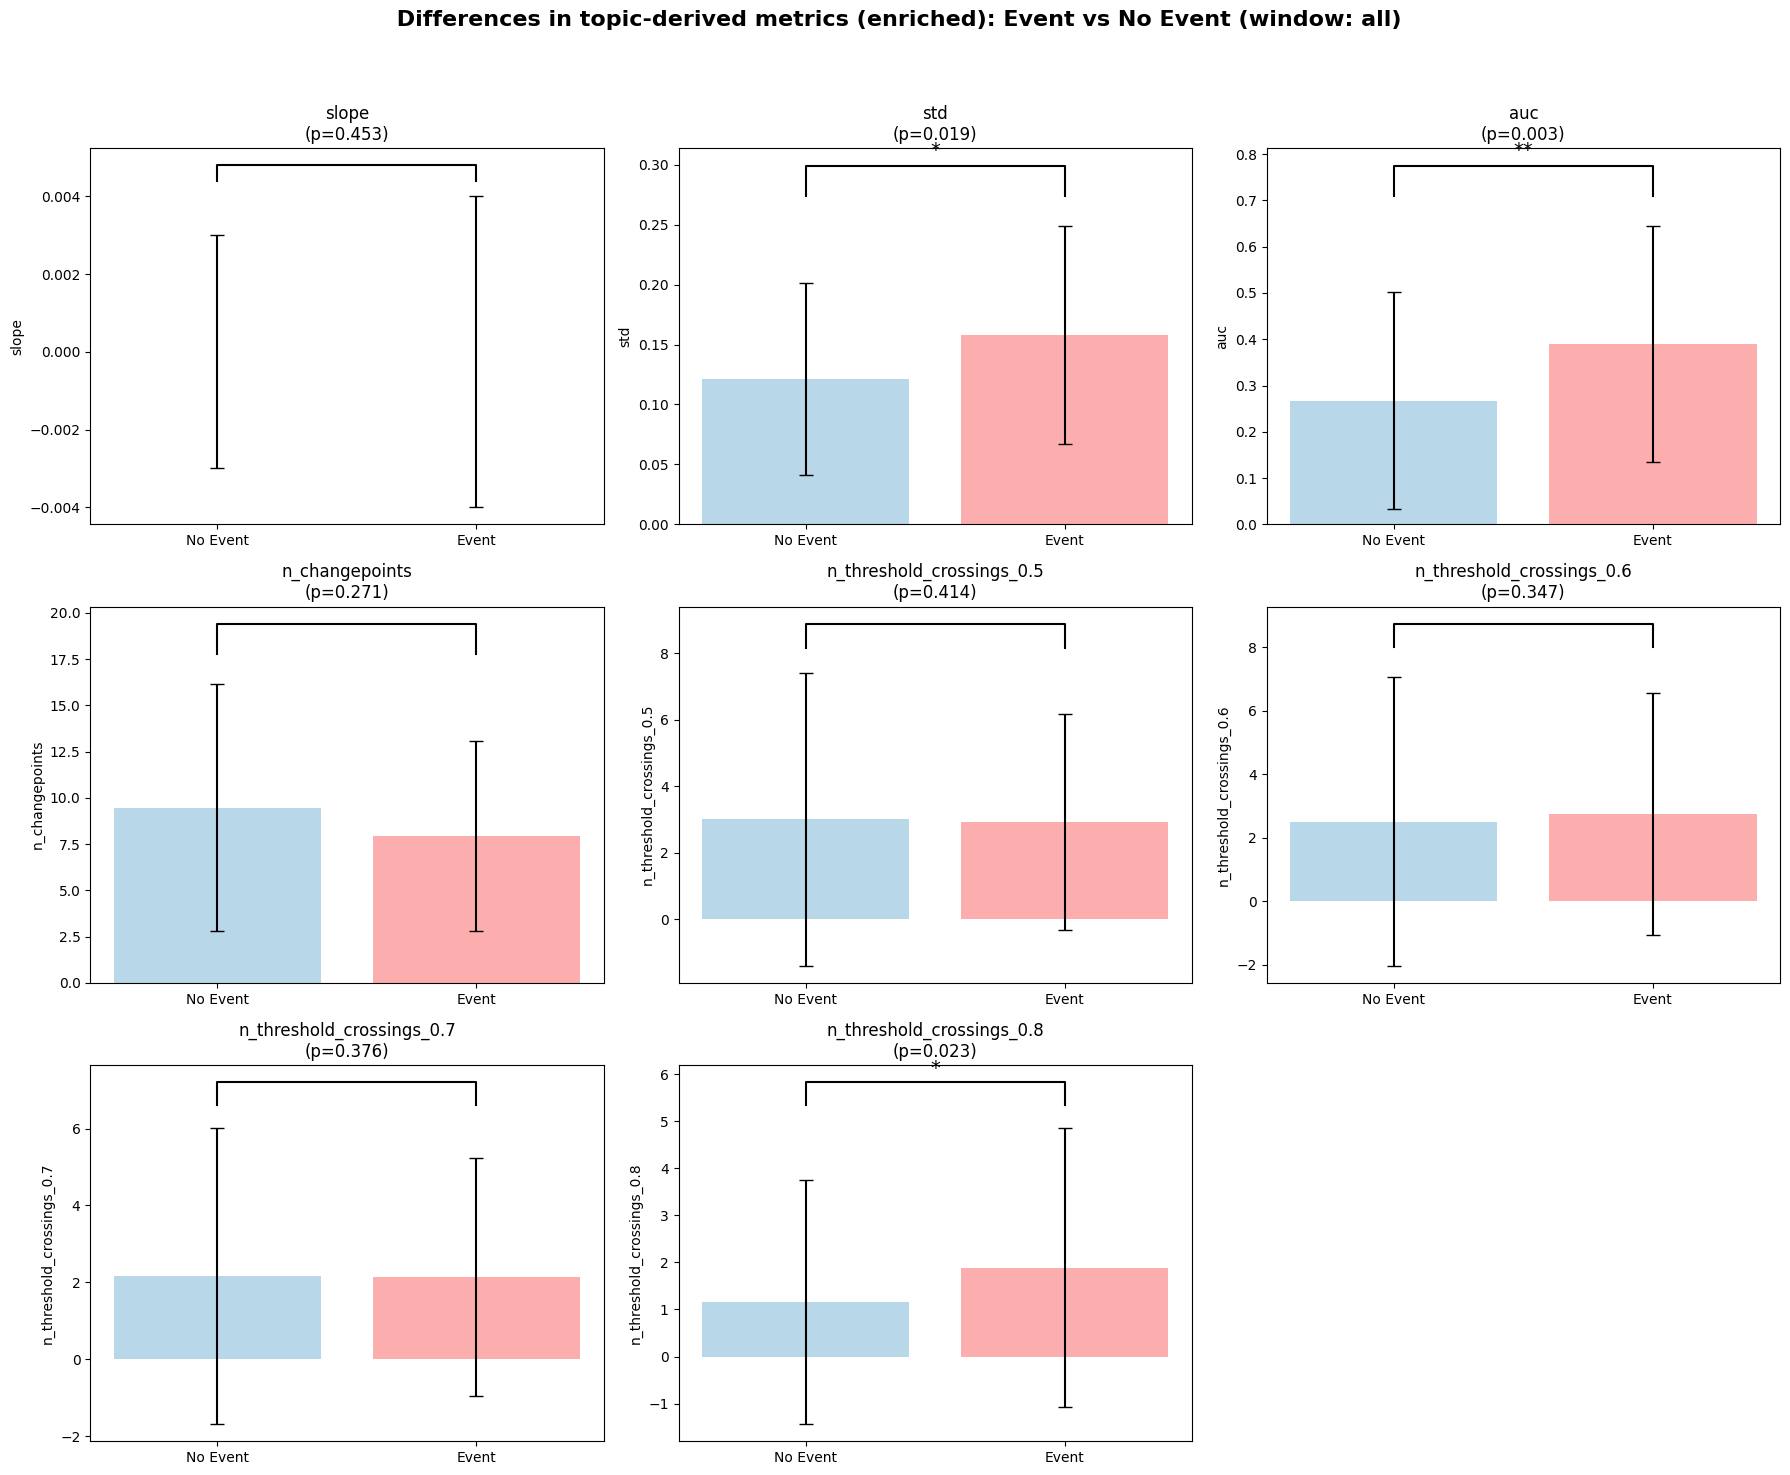

Figura guardada en /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/statistical_by_window/barplots_metrics_first_90_days_PDTopics_3+5.png


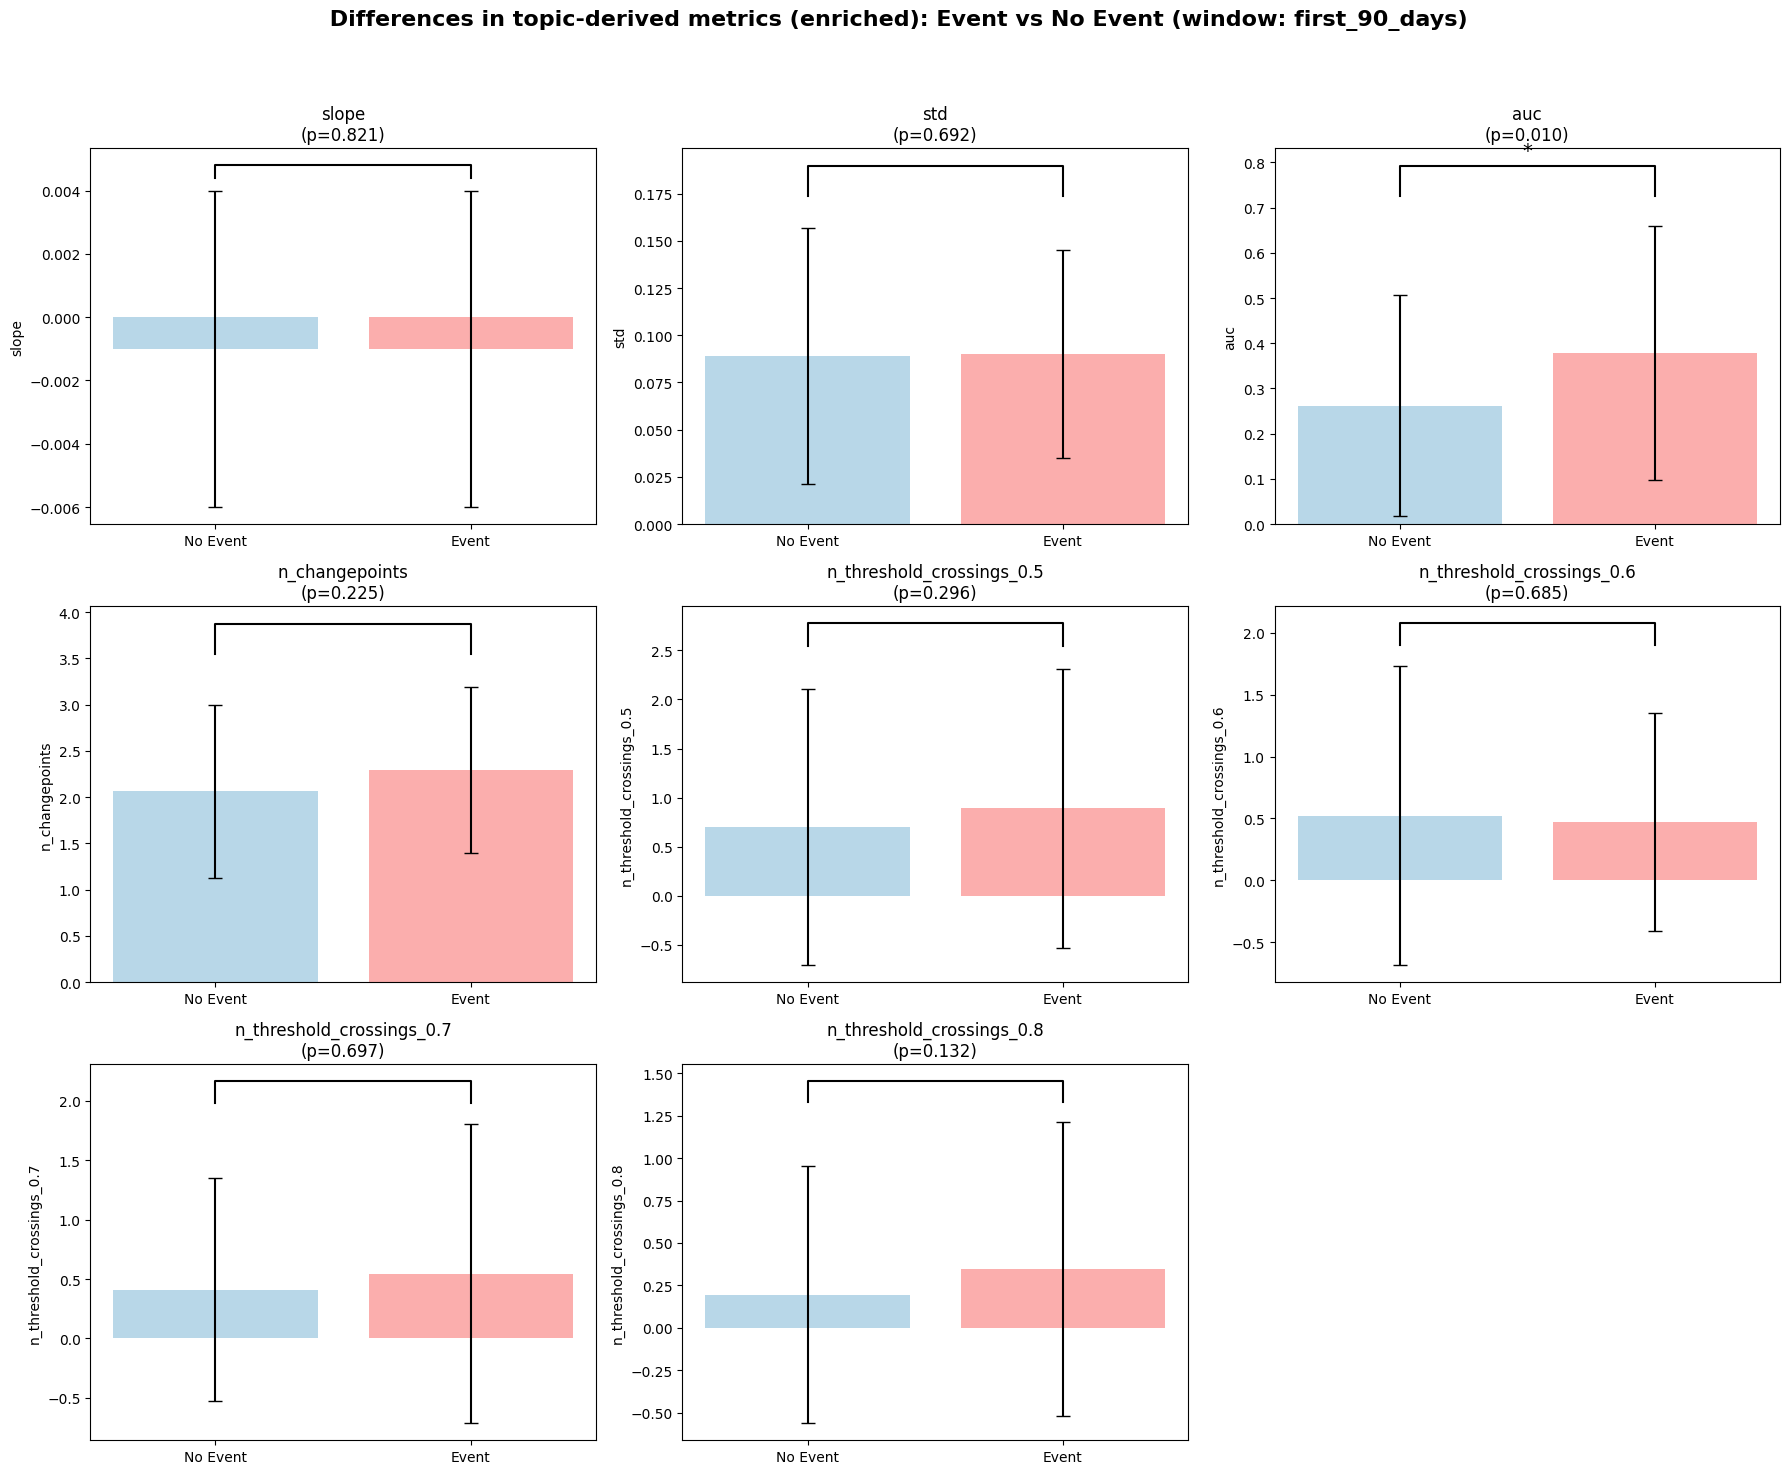

Figura guardada en /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/statistical_by_window/barplots_metrics_first_60_days_PDTopics_3+5.png


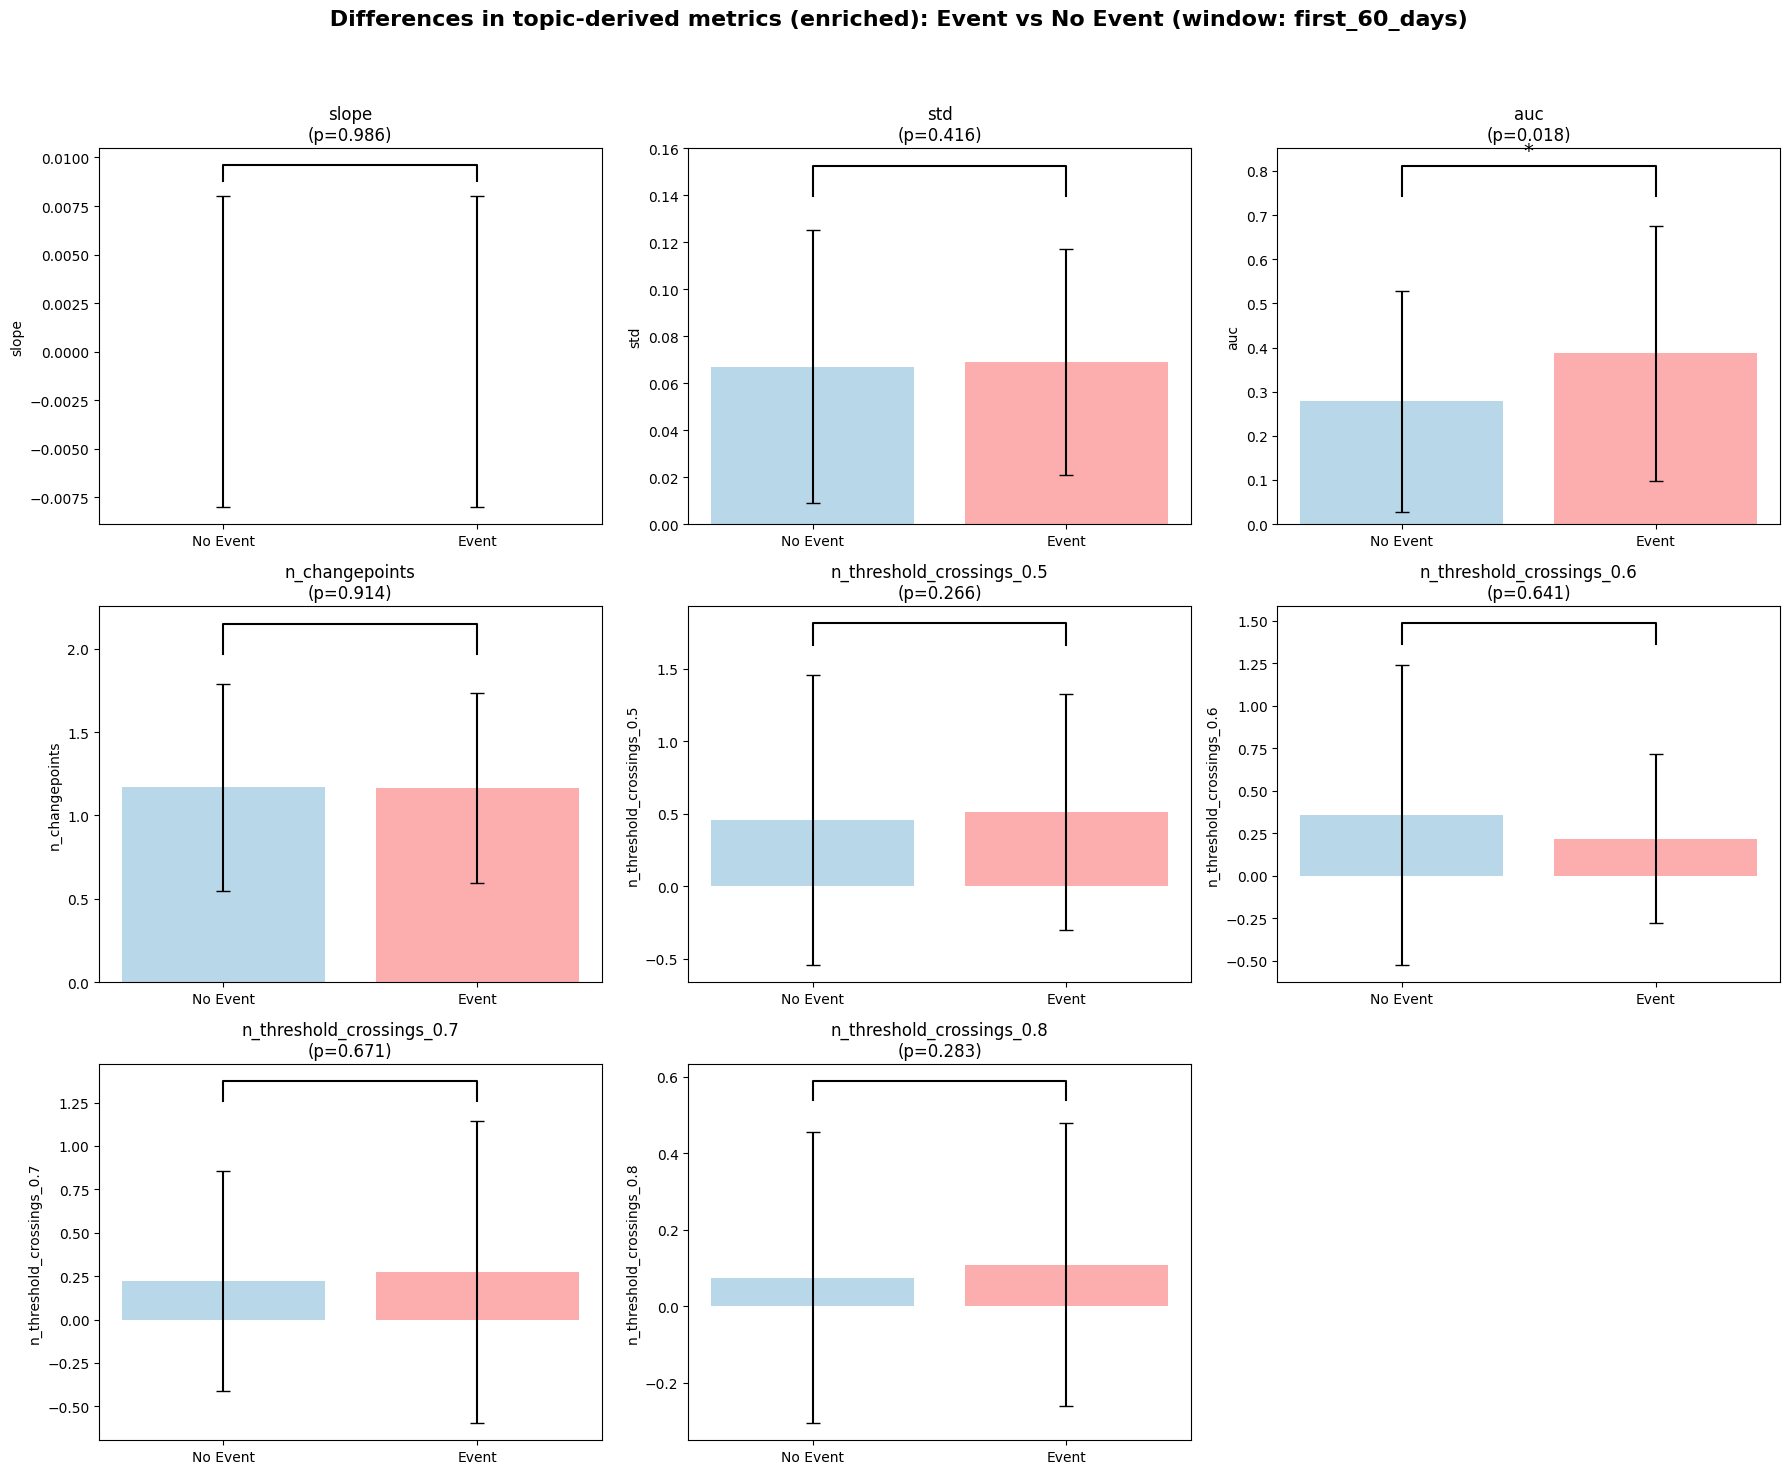

In [27]:
plot_metrics_barplots_by_window(
    df_stats,bad_topics='3+5',
    save_dir=module_path+"/2nd_phase/results/statistical_by_window"
)


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_metrics_barplots_by_window_horizontal(df_stats,bad_topics='3', save_dir=None):
    """
    Barplots de mean ± std para cada métrica, alineados en una fila horizontal
    por cada tipo de ventana temporal.
    """
    windows = df_stats["window"].unique()
    
    for win in windows:
        df_win = df_stats[df_stats["window"] == win]
        metrics = df_win["metric"].unique()
        n_metrics = len(metrics)

        fig, axes = plt.subplots(1, n_metrics, figsize=(4*n_metrics, 5), squeeze=False)
        axes = axes.flatten()

        for ax, metric in zip(axes, metrics):
            row = df_win[df_win["metric"] == metric].iloc[0]

            means = [row["mean_no_event"], row["mean_event"]]
            stds = [row["std_no_event"], row["std_event"]]
            groups = ["No Event", "Event"]

            ax.bar(groups, means, yerr=stds, capsize=5, 
                   color=["#a6cee3", "#fb9a99"], alpha=0.8)

            # Añadir significancia
            star = row["significance"]
            pval = row["p_value"]

            y_max = max(means) + max(stds)
            h = y_max * 0.15
            x1, x2 = 0, 1
            ax.plot([x1, x1, x2, x2],
                    [y_max+h, y_max+2*h, y_max+2*h, y_max+h],
                    lw=1.5, c='k')
            ax.text((x1+x2)/2, y_max+2.3*h, star,
                    ha='center', va='bottom', fontsize=14)

            ax.set_title(f"{metric}\n(p={pval:.3f})", fontsize=11)
            ax.set_ylabel(metric)

        # ajustar márgenes para no cortar asteriscos
        #fig.suptitle(f" Differences in topic-derived metrics: Event vs No Event (window: {win})", fontsize=16, fontweight="bold")
        fig.suptitle(f" Differences in topic-derived metrics (enriched): Event vs No Event (window: {win})", fontsize=16, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.9])  # deja espacio arriba
        plt.subplots_adjust(top=0.8)           # más margen superior

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"barplots_metrics_{win}_PDTopics_{bad_topics}_horizontal.png")
            plt.savefig(save_path, dpi=300)
            print(f"Figura guardada en {save_path}")

        plt.show()


Figura guardada en /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/statistical_by_window/barplots_metrics_all_PDTopics_3+4+5_horizontal.png


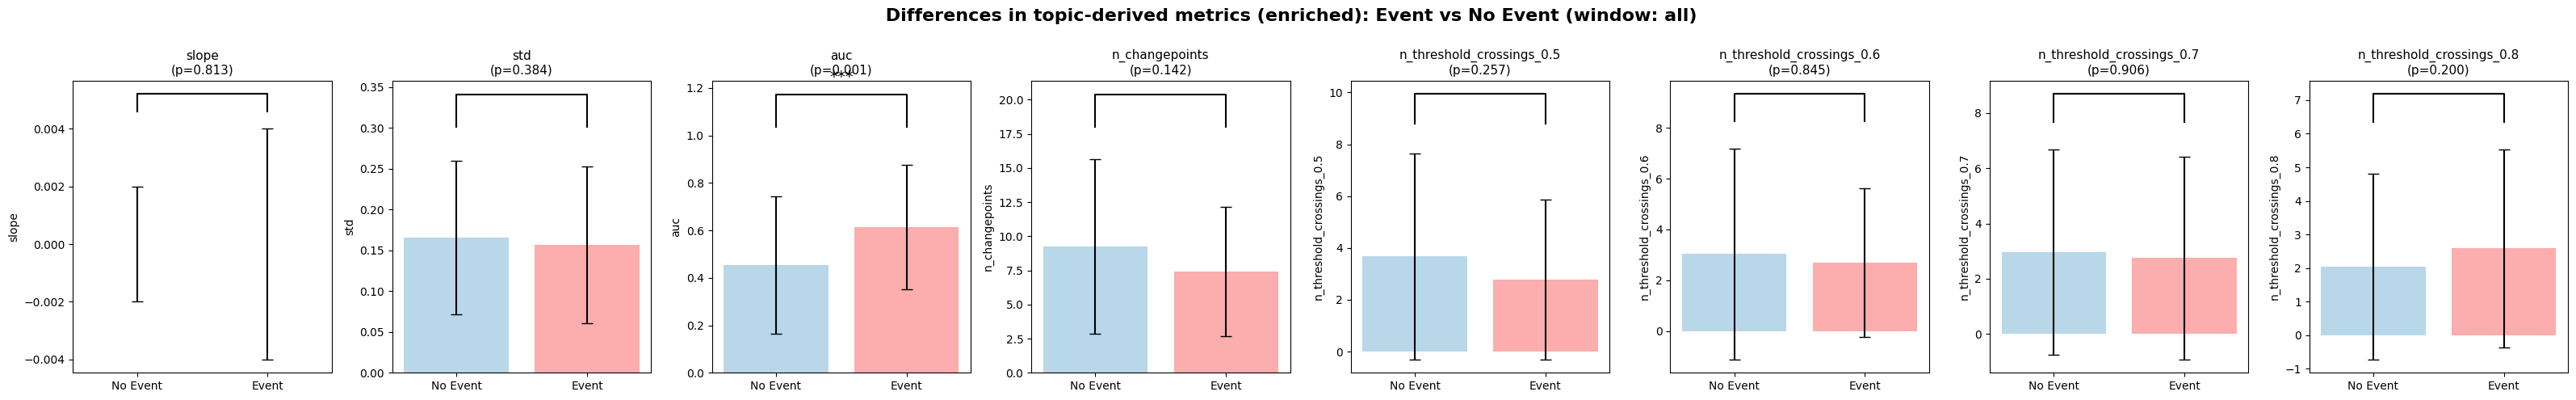

Figura guardada en /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/statistical_by_window/barplots_metrics_first_90_days_PDTopics_3+4+5_horizontal.png


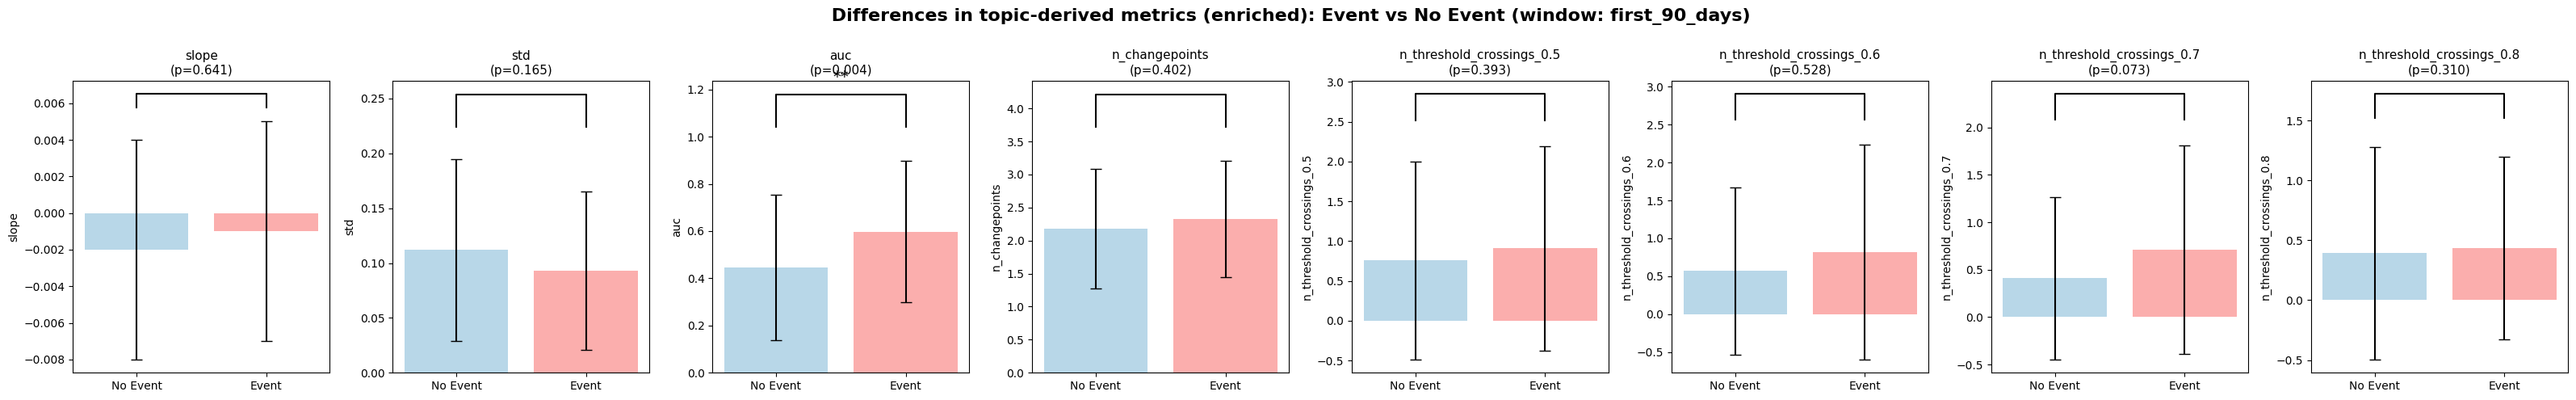

Figura guardada en /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/statistical_by_window/barplots_metrics_first_60_days_PDTopics_3+4+5_horizontal.png


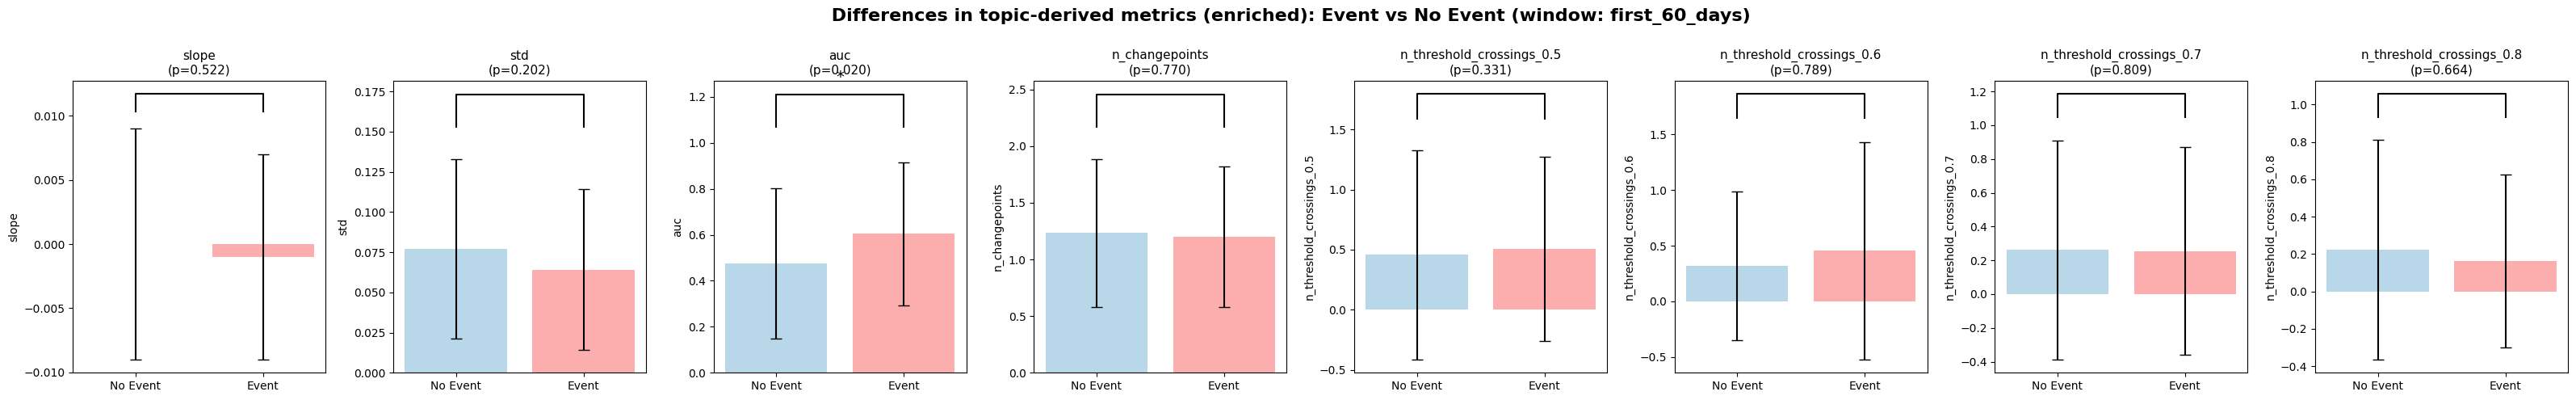

In [31]:
plot_metrics_barplots_by_window_horizontal(
    df_stats,bad_topics='3+4+5',
    save_dir=module_path+"/2nd_phase/results/statistical_by_window"
)


# Alarmas

## Tiempo de latencia

## Formato I

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def analyze_early_auc_prediction(df, lda_model, dictionary, n_topic_days=90, N_days_limit=730, bad_topics=[3, 4, 5]):
    results = []

    for _, row in df.iterrows():
        patient_id = row['id']
        
        # Etiqueta: 1 si el evento ocurrió antes o igual al límite N
        is_fast_progressor = 1 if (row['Evento PD'] == 1 and row['Evento PD diff'] <= N_days_limit) else 0
        
        topic_distributions = get_topic_distributions_with_entropy(
            df, patient_id, lda_model, dictionary, window_size=30)

        if topic_distributions and len(topic_distributions) > 0:
            prob_bad_daily = get_bad_topic_probabilities(topic_distributions, bad_topics)
            
            # Cogemos la "ventana de observación" (ej. primeros 90 días)
            early_probs = prob_bad_daily[:n_topic_days]
            
            if len(early_probs) >= 10: 
                auc_early = np.mean(early_probs)
                
                results.append({
                    'id': patient_id,
                    'auc_early': auc_early,
                    'fast_progression': is_fast_progressor,
                    'time_to_event': row['Evento PD diff'] if row['Evento PD'] == 1 else np.nan
                })

    df_auc = pd.DataFrame(results)

    # --- GENERACIÓN DEL REPORTE ---
    total_patients = len(df_auc)
    fast_pd_count = df_auc['fast_progression'].sum()
    others_count = total_patients - fast_pd_count
    
    # Media de tiempo de progresión solo de los que son Fast PD
    avg_time_fast = df_auc[df_auc['fast_progression'] == 1]['time_to_event'].mean()

    print("="*40)
    print(f"📊 REPORT (Limit N = {N_days_limit} days)")
    print("="*40)
    print(f"Total patients analyzed:     {total_patients}")
    print(f"Fast PD cases (Early):       {fast_pd_count}")
    print(f"Others (Slow PD or No-PD):   {others_count}")
    if fast_pd_count > 0:
        print(f"Avg. Progression Time (Fast): {avg_time_fast:.2f} days")
    else:
        print("Avg. Progression Time (Fast): N/A")
    print("="*40)

    return df_auc



In [6]:
def analyze_early_auc_prediction(df, lda_model, dictionary, n_topic_days=90, N_days_limit=730, bad_topics=[3, 4, 5]):
    results = []
    
    # Contadores para el reporte de descartados
    count_no_data = 0
    count_insufficient = 0

    for _, row in df.iterrows():
        patient_id = row['id']
        
        # Etiqueta: 1 si el evento ocurrió antes o igual al límite N
        is_fast_progressor = 1 if (row['Evento PD'] == 1 and row['Evento PD diff'] <= N_days_limit) else 0
        
        topic_distributions = get_topic_distributions_with_entropy(
            df, patient_id, lda_model, dictionary, window_size=30)

        # 1. Verificación si el paciente tiene datos
        if not topic_distributions or len(topic_distributions) == 0:
            count_no_data += 1
            continue

        prob_bad_daily = get_bad_topic_probabilities(topic_distributions, bad_topics)
        
        # Cogemos la "ventana de observación" (ej. primeros 90 días)
        early_probs = prob_bad_daily[:n_topic_days]
        
        # 2. Verificación de cantidad mínima de datos (10 días)
        if len(early_probs) < 10:
            count_insufficient += 1
            continue
            
        auc_early = np.mean(early_probs)
        
        results.append({
            'id': patient_id,
            'auc_early': auc_early,
            'fast_progression': is_fast_progressor,
            'time_to_event': row['Evento PD diff'] if row['Evento PD'] == 1 else np.nan,
            'days_observed': len(early_probs)
        })

    df_auc = pd.DataFrame(results)

    # --- GENERACIÓN DEL REPORTE MEJORADO ---
    total_input = len(df)
    total_analyzed = len(df_auc)
    fast_pd_count = df_auc['fast_progression'].sum()
    others_count = total_analyzed - fast_pd_count
    avg_time_fast = df_auc[df_auc['fast_progression'] == 1]['time_to_event'].mean()

    print("="*50)
    print(f"📊 FINAL REPORT (Prediction Limit N = {N_days_limit} days)")
    print("="*50)
    print(f"Initial patients in DF:      {total_input}")
    print(f"DISCARDED - No diary data:   {count_no_data}")
    print(f"DISCARDED - < 10 days data:  {count_insufficient}")
    print(f"TOTAL ANALYZED:              {total_analyzed}")
    print("-" * 50)
    print(f"Fast PD cases (Target):      {fast_pd_count}")
    print(f"Others (Slow/No-PD):         {others_count}")
    
    if fast_pd_count > 0:
        print(f"Avg. Time to Event (Fast):   {avg_time_fast:.2f} days")
    
    # Cálculo de prevalencia de la clase positiva
    prevalence = (fast_pd_count / total_analyzed) * 100 if total_analyzed > 0 else 0
    print(f"Prevalence of Fast PD:       {prevalence:.1f}%")
    print("="*50)

    return df_auc

In [11]:
df_day

,id,predominant_topic,topic_distribution,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,embedding_ids,Fecha_entrada_HDM,Evento PD,Tiempo Obs Final,diferencia,Evento PD diff,early PD
0,11001,3,"[0.00019024033, 0.094892785, 0.00019086628, 0....",0.000190,0.094893,0.000191,0.692382,0.017605,0.194739,"[67, 34, 194, 7, 76, 49, 95, 62, 131, 175, 58,...",2023-04-19,0,876,0.0,876.0,0
1,11003,3,"[0.00047766662, 0.056067478, 0.023019955, 0.67...",0.000478,0.056067,0.023020,0.670386,0.068694,0.181354,"[46, 13, 184, 225, 192, 224, 72, 224, 197, 180...",2023-12-05,1,357,8.0,349.0,0
2,11004,2,"[0.00026418606, 0.12145818, 0.51455325, 0.2545...",0.000264,0.121458,0.514553,0.254527,0.082532,0.026666,"[43, 43, 218, 210, 77, 34, 243, 125, 125, 218,...",2023-12-20,0,631,0.0,631.0,0
3,11005,1,"[0.031426333, 0.7207797, 0.1621154, 0.00031404...",0.031426,0.720780,0.162115,0.000314,0.000315,0.085049,"[238, 172, 50, 110, 125, 117, 18, 18, 149, 14,...",2024-03-27,0,533,0.0,533.0,0
4,11006,2,"[0.0005627643, 0.072490364, 0.63257277, 0.0005...",0.000563,0.072490,0.632573,0.000568,0.293243,0.000563,"[247, 69, 91, 142, 125, 208, 208, 15, 247, 51,...",2024-11-20,0,295,0.0,295.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,91019,1,"[0.0009017797, 0.7635105, 0.16361338, 0.000910...",0.000902,0.763510,0.163613,0.000910,0.000903,0.070161,"[248, 168, 66, 8, 76, 72, 224, 243, 78, 40, 40...",2025-03-12,0,183,0.0,183.0,0
171,92001,5,"[0.00037217292, 0.29675072, 0.15215692, 0.1471...",0.000372,0.296751,0.152157,0.147150,0.082167,0.321403,"[141, 81, 81, 61, 229, 196, 122, 236, 81, 81, ...",2024-07-18,1,448,0.0,448.0,0
172,92002,2,"[0.0064248946, 0.2389276, 0.4191231, 0.0065088...",0.006425,0.238928,0.419123,0.006509,0.322528,0.006487,"[24, 117, 165, 246, 250, 220, 45, 188, 85, 76,...",2024-09-06,1,28,4.0,24.0,1
173,93001,4,"[0.00104108, 0.12403497, 0.17489672, 0.1237319...",0.001041,0.124035,0.174897,0.123732,0.498813,0.077482,"[107, 77, 178, 48, 28, 1, 31, 109, 213, 136, 1...",2023-12-07,1,163,4.0,159.0,1


📊 FINAL REPORT (Prediction Limit N = 120 days)
Initial patients in DF:      175
DISCARDED - No diary data:   11
DISCARDED - < 10 days data:  4
TOTAL ANALYZED:              160
--------------------------------------------------
Fast PD cases (Target):      9
Others (Slow/No-PD):         151
Avg. Time to Event (Fast):   82.67 days
Prevalence of Fast PD:       5.6%


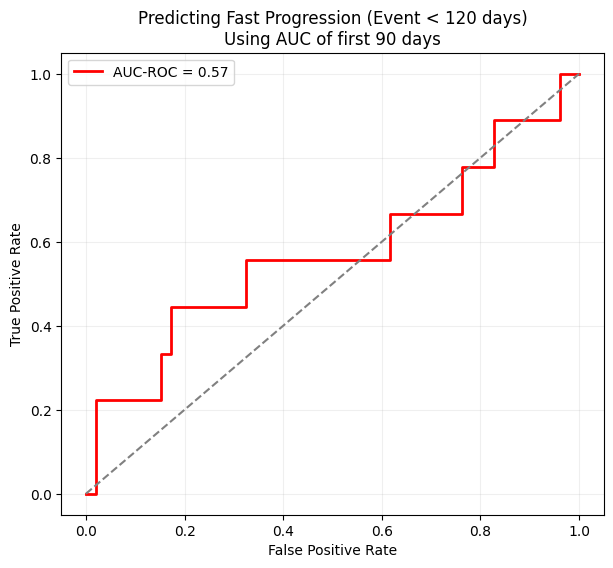

In [12]:
N_days_limit=120
# --- EJECUCIÓN ---
# N_days_limit = 730 (Queremos predecir quién tendrá el evento en los primeros 2 años)
df_prediction = analyze_early_auc_prediction(df_day, lda_model, dictionary, N_days_limit=N_days_limit)


# --- CÁLCULO DE ROC ---
fpr, tpr, thresholds = roc_curve(df_prediction['fast_progression'], df_prediction['auc_early'])
roc_auc = auc(fpr, tpr)

# --- PLOT ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.2f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f'Predicting Fast Progression (Event < {N_days_limit} days)\nUsing AUC of first 90 days')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

📊 FINAL REPORT (Prediction Limit N = 150 days)
Initial patients in DF:      175
DISCARDED - No diary data:   11
DISCARDED - < 10 days data:  4
TOTAL ANALYZED:              160
--------------------------------------------------
Fast PD cases (Target):      11
Others (Slow/No-PD):         149
Avg. Time to Event (Fast):   92.73 days
Prevalence of Fast PD:       6.9%


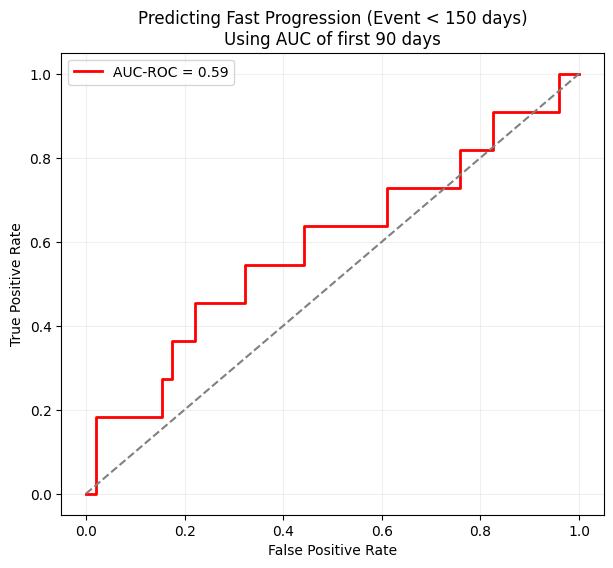

In [33]:

n_topic_days=90
N_days_limit=150

# --- EJECUCIÓN ---
# N_days_limit = 730 (Queremos predecir quién tendrá el evento en los primeros 2 años)
df_prediction = analyze_early_auc_prediction(df_day, lda_model, dictionary,n_topic_days=n_topic_days, N_days_limit=N_days_limit)


# --- CÁLCULO DE ROC ---
fpr, tpr, thresholds = roc_curve(df_prediction['fast_progression'], df_prediction['auc_early'])
roc_auc = auc(fpr, tpr)

# --- PLOT ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.2f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f'Predicting Fast Progression (Event < {N_days_limit} days)\nUsing AUC of first {n_topic_days} days')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

📊 FINAL REPORT (Prediction Limit N = 180 days)
Initial patients in DF:      175
DISCARDED - No diary data:   11
DISCARDED - < 10 days data:  4
TOTAL ANALYZED:              160
--------------------------------------------------
Fast PD cases (Target):      18
Others (Slow/No-PD):         142
Avg. Time to Event (Fast):   119.83 days
Prevalence of Fast PD:       11.2%


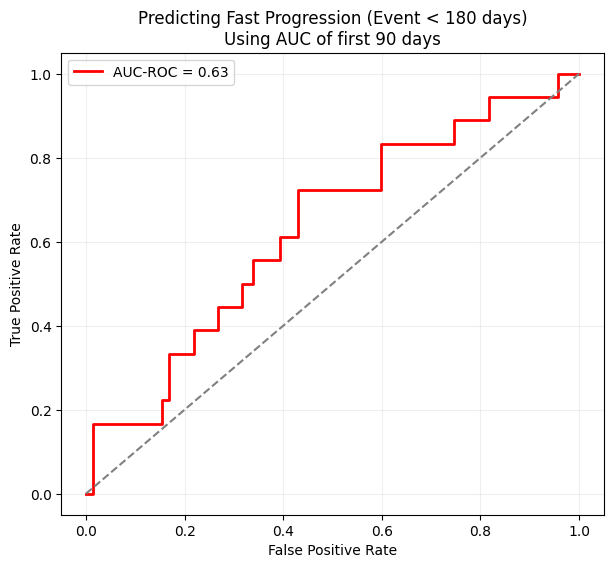

In [34]:

n_topic_days=90
N_days_limit=180

# --- EJECUCIÓN ---
# N_days_limit = 730 (Queremos predecir quién tendrá el evento en los primeros 2 años)
df_prediction = analyze_early_auc_prediction(df_day, lda_model, dictionary,n_topic_days=n_topic_days, N_days_limit=N_days_limit)


# --- CÁLCULO DE ROC ---
fpr, tpr, thresholds = roc_curve(df_prediction['fast_progression'], df_prediction['auc_early'])
roc_auc = auc(fpr, tpr)

# --- PLOT ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.2f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f'Predicting Fast Progression (Event < {N_days_limit} days)\nUsing AUC of first {n_topic_days} days')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

📊 FINAL REPORT (Prediction Limit N = 150 days)
Initial patients in DF:      175
DISCARDED - No diary data:   11
DISCARDED - < 10 days data:  4
TOTAL ANALYZED:              160
--------------------------------------------------
Fast PD cases (Target):      11
Others (Slow/No-PD):         149
Avg. Time to Event (Fast):   92.73 days
Prevalence of Fast PD:       6.9%


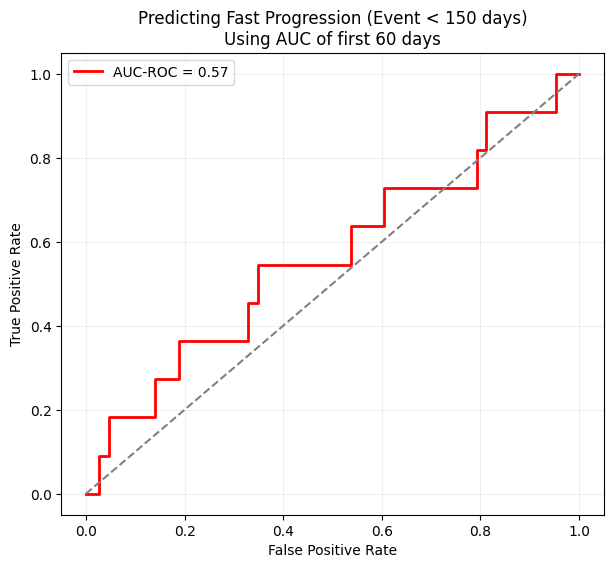

In [35]:

n_topic_days=60
N_days_limit=150

# --- EJECUCIÓN ---
# N_days_limit = 730 (Queremos predecir quién tendrá el evento en los primeros 2 años)
df_prediction = analyze_early_auc_prediction(df_day, lda_model, dictionary,n_topic_days=n_topic_days, N_days_limit=N_days_limit)


# --- CÁLCULO DE ROC ---
fpr, tpr, thresholds = roc_curve(df_prediction['fast_progression'], df_prediction['auc_early'])
roc_auc = auc(fpr, tpr)

# --- PLOT ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.2f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f'Predicting Fast Progression (Event < {N_days_limit} days)\nUsing AUC of first {n_topic_days} days')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

📊 FINAL REPORT (Prediction Limit N = 180 days)
Initial patients in DF:      175
DISCARDED - No diary data:   11
DISCARDED - < 10 days data:  4
TOTAL ANALYZED:              160
--------------------------------------------------
Fast PD cases (Target):      18
Others (Slow/No-PD):         142
Avg. Time to Event (Fast):   119.83 days
Prevalence of Fast PD:       11.2%


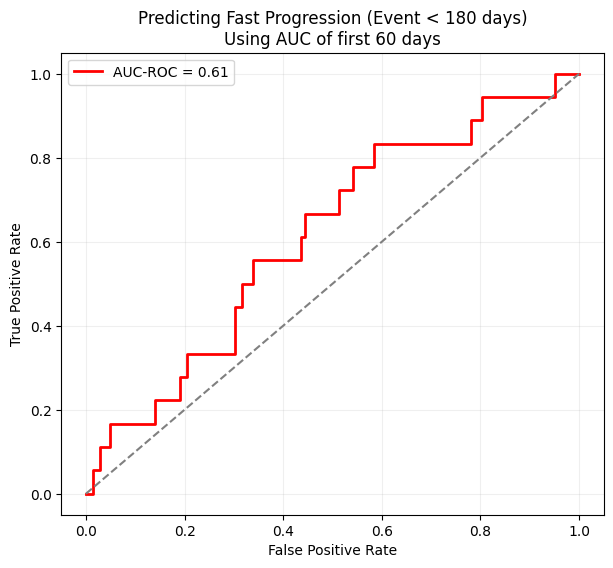

In [37]:

n_topic_days=60
N_days_limit=180

# --- EJECUCIÓN ---
# N_days_limit = 730 (Queremos predecir quién tendrá el evento en los primeros 2 años)
df_prediction = analyze_early_auc_prediction(df_day, lda_model, dictionary,n_topic_days=n_topic_days, N_days_limit=N_days_limit)


# --- CÁLCULO DE ROC ---
fpr, tpr, thresholds = roc_curve(df_prediction['fast_progression'], df_prediction['auc_early'])
roc_auc = auc(fpr, tpr)

# --- PLOT ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.2f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f'Predicting Fast Progression (Event < {N_days_limit} days)\nUsing AUC of first {n_topic_days} days')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### auc eliminando los que tienen menos de 80% de datoss

In [38]:
def analyze_early_auc_prediction(df, lda_model, dictionary, n_topic_days=90, N_days_limit=730, bad_topics=[3, 4, 5]):
    results = []
    skipped_count = 0

    for _, row in df.iterrows():
        patient_id = row['id']
        is_fast_progressor = 1 if (row['Evento PD'] == 1 and row['Evento PD diff'] <= N_days_limit) else 0
        
        topic_distributions = get_topic_distributions_with_entropy(
            df, patient_id, lda_model, dictionary, window_size=30)

        if topic_distributions:
            prob_bad_daily = get_bad_topic_probabilities(topic_distributions, bad_topics)
            early_probs = prob_bad_daily[:n_topic_days]
            
            # --- CAMBIO: Solo incluimos si tiene AL MENOS el 80% de los días requeridos ---
            # Si pides 90 días, al menos debe tener 72 días para ser comparable
            min_days_required = n_topic_days * 0.5 
            
            if len(early_probs) >= min_days_required:
                auc_early = np.mean(early_probs)
                results.append({
                    'id': patient_id,
                    'auc_early': auc_early,
                    'fast_progression': is_fast_progressor,
                    'time_to_event': row['Evento PD diff'] if row['Evento PD'] == 1 else np.nan,
                    'data_completeness': len(early_probs) / n_topic_days
                })
            else:
                skipped_count += 1

    df_auc = pd.DataFrame(results)

    # --- REPORTE MEJORADO ---
    total_analyzed = len(df_auc)
    fast_pd = df_auc['fast_progression'].sum()
    avg_time = df_auc[df_auc['fast_progression'] == 1]['time_to_event'].mean()

    print(f"📊 REPORT (Window: {n_topic_days} days | Limit N: {N_days_limit} days)")
    print("-" * 50)
    print(f"Patients included:           {total_analyzed}")
    print(f"Patients discarded (Short):  {skipped_count}  <-- Estos no tenían suficientes días")
    print(f"Fast PD detected:            {fast_pd}")
    print(f"Mean Time to Event (Fast):   {avg_time:.2f} days")
    print("-" * 50)

    return df_auc

📊 REPORT (Window: 60 days | Limit N: 180 days)
--------------------------------------------------
Patients included:           155
Patients discarded (Short):  9  <-- Estos no tenían suficientes días
Fast PD detected:            18
Mean Time to Event (Fast):   119.83 days
--------------------------------------------------


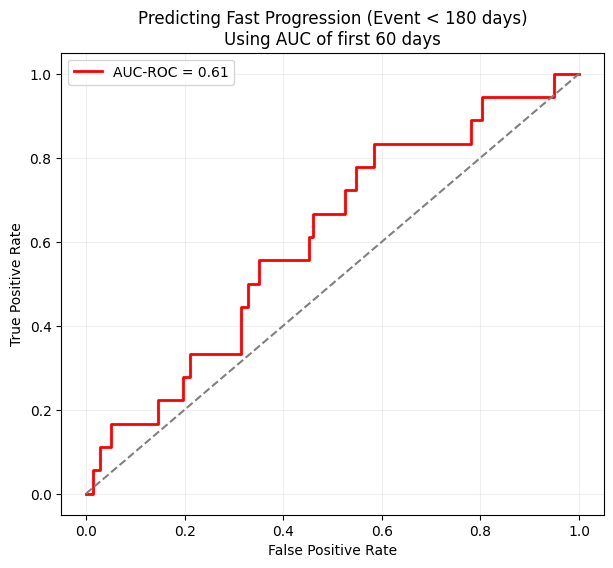

In [39]:

n_topic_days=60
N_days_limit=180

# --- EJECUCIÓN ---
# N_days_limit = 730 (Queremos predecir quién tendrá el evento en los primeros 2 años)
df_prediction = analyze_early_auc_prediction(df_day, lda_model, dictionary,n_topic_days=n_topic_days, N_days_limit=N_days_limit)


# --- CÁLCULO DE ROC ---
fpr, tpr, thresholds = roc_curve(df_prediction['fast_progression'], df_prediction['auc_early'])
roc_auc = auc(fpr, tpr)

# --- PLOT ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.2f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f'Predicting Fast Progression (Event < {N_days_limit} days)\nUsing AUC of first {n_topic_days} days')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# alarma dinámica

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc


def get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size=30, min_size=15):
    row = df[df['id'] == patient_id]
    if row.empty:
        # No imprimimos para no saturar la consola durante la ROC
        return []

    embedding_ids = row.iloc[0]['embedding_ids']
    
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)
    
    n_tokens = len(embedding_ids)
    topic_distributions = []

    # CASO 1: El paciente tiene suficientes datos para la ventana estándar (30)
    if n_tokens >= window_size:
        for start in range(0, n_tokens - window_size + 1):
            window = embedding_ids[start:start + window_size]
            bow = dictionary.doc2bow([str(token) for token in window])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
            topic_distributions.append(topic_probs)

    # CASO 2: El paciente es "corto" (entre 15 y 29 días)
    # Relajamos la métrica: calculamos una única distribución con lo que tenga
    elif n_tokens >= min_size:
        # Usamos todos los tokens disponibles como una única ventana
        bow = dictionary.doc2bow([str(token) for token in embedding_ids])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
        topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        
        # Para que el resto del código funcione, devolvemos esto como una lista
        # de un solo día (o repetimos para simular consistencia si fuera necesario)
        topic_distributions.append(topic_probs)

    return topic_distributions

def analyze_dynamic_alarm_system(df, lda_model, dictionary, threshold_t=0.6, N_days_window=120, bad_topics=[3, 4, 5], silent=False):
    """
    Sistema de alerta temprana basado en la carga acumulada (AUC dinámica) de tópicos negativos.
    """
    results = []
    detailed_counts = {
        'TP': 0, 'FP_no_event': 0, 'FP_too_early': 0,
        'FN_no_alarm': 0, 'FN_late': 0, 'TN': 0
    }
    
    # Reporte de exclusión
    exclusion_report = {
        'total_input': len(df),
        'no_topic_data': 0,
        'ids_no_data': [],
        'analyzed': 0
    }

    for _, row in df.iterrows():
        patient_id = row['id']
        has_pd_event = (row['Evento PD'] == 1)
        time_to_pd = row['Evento PD diff']
        
        # Intentar obtener distribuciones
        topic_distributions = get_topic_distributions_with_entropy(
            df, patient_id, lda_model, dictionary, window_size=30)
        
        # Caso de descarte: No hay datos procesables para este paciente
        if not topic_distributions or len(topic_distributions) == 0:
            exclusion_report['no_topic_data'] += 1
            exclusion_report['ids_no_data'].append(patient_id)
            continue
            
        prob_bad_daily = get_bad_topic_probabilities(topic_distributions, bad_topics)
        
        # Caso de descarte: Lista de probabilidades vacía tras el filtrado
        if len(prob_bad_daily) == 0:
            exclusion_report['no_topic_data'] += 1
            exclusion_report['ids_no_data'].append(patient_id)
            continue

        exclusion_report['analyzed'] += 1
        
        alarm_day = None
        # Monitoreo diario (mínimo 10 días para estabilidad)
        for d in range(10, len(prob_bad_daily)):
            current_cumulative_auc = np.mean(prob_bad_daily[:d])
            if current_cumulative_auc >= threshold_t:
                alarm_day = d
                break 
        print('---------------------- pacinete: ',patient_id,'----------------------')
        print('Topic distribution: ',prob_bad_daily)
        print('alarm day: ',d)
        print('Tiene event0:', has_pd_event )
        print('Evento PD diff', time_to_pd )
     
        
        
        final_case = ""
        if has_pd_event:
            if alarm_day is None:
                final_case = 'FN_no_alarm'
            elif alarm_day >= time_to_pd:
                final_case = 'FN_late'
            elif alarm_day < time_to_pd <= (alarm_day + N_days_window):
                final_case = 'TP'
            else:
                final_case = 'FP_too_early'
        else:
            if alarm_day is not None:
                final_case = 'FP_no_event'
            else:
                final_case = 'TN'

        detailed_counts[final_case] += 1
        results.append({'id': patient_id, 'case': final_case, 'alarm_day': alarm_day})

    # Métricas consolidadas
    tp = detailed_counts['TP']
    fp = detailed_counts['FP_no_event'] + detailed_counts['FP_too_early']
    fn = detailed_counts['FN_no_alarm'] + detailed_counts['FN_late']
    tn = detailed_counts['TN']
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    if not silent:
        print("\n" + "="*60)
        print("📋 REPORTE DE EXCLUSIÓN Y POBLACIÓN")
        print("="*60)
        print(f"Pacientes iniciales:          {exclusion_report['total_input']}")
        print(f"Descartados (sin datos):     {exclusion_report['no_topic_data']}")
        print(f"Pacientes analizados:         {exclusion_report['analyzed']}")
        if exclusion_report['ids_no_data']:
            print(f"IDs descartados (ejemplos):  {exclusion_report['ids_no_data'][:5]}...")
        
        print("\n" + "="*60)
        print(f"📊 RENDIMIENTO DE ALARMA (T={threshold_t:.2f}, N={N_days_window})")
        print("="*60)
        print(f"TPR (Sensibilidad):           {tpr:.2%}")
        print(f"FPR (1-Especificidad):        {fpr:.2%}")
        print(f"Casos TP: {tp} | FN: {fn} | FP: {fp} | TN: {tn}")
        print("="*60 + "\n")

    return tpr, fpr, exclusion_report

def plot_dynamic_roc_curve(df, lda_model, dictionary, N_days_window=120, bad_topics=[3, 4, 5]):
    """
    Genera una curva ROC iterando sobre diferentes umbrales T.
    """
    t_thresholds = np.linspace(0.05, 0.95, 10)
    #t_thresholds=[0.5,0.7,0.8]
    tpr_list = []
    fpr_list = []

    print("Calculando puntos de la curva ROC...")
    for t in t_thresholds:
        tpr, fpr, _ = analyze_dynamic_alarm_system(
            df, lda_model, dictionary, 
            threshold_t=t, 
            N_days_window=N_days_window, 
            bad_topics=bad_topics, 
            silent=False
        )
        tpr_list.append(tpr)
        fpr_list.append(fpr)

    points = sorted(zip(fpr_list, tpr_list))
    fpr_sorted, tpr_sorted = zip(*points)
    roc_auc = auc(fpr_sorted, tpr_sorted)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_sorted, tpr_sorted, color='darkorange', lw=2, label=f'ROC Dinámica (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    # Etiquetas de umbral
    for i, t in enumerate(t_thresholds):
        if i % 4 == 0:
            plt.annotate(f"T={t:.1f}", (fpr_list[i], tpr_list[i]), textcoords="offset points", xytext=(0,10), ha='center')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    plt.title(f'Curva ROC - Sistema de Alarma\n(Ventana N = {N_days_window} días)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return roc_auc

# Ejemplo de uso:
# tpr, fpr, report = analyze_dynamic_alarm_system(df, lda_model, dictionary)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import ast

def get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size=30, min_size=15):
    row = df[df['id'] == patient_id]
    if row.empty:
        return []

    embedding_ids = row.iloc[0]['embedding_ids']
    
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)
    
    n_tokens = len(embedding_ids)
    topic_distributions = []

    if n_tokens >= window_size:
        for start in range(0, n_tokens - window_size + 1):
            window = embedding_ids[start:start + window_size]
            bow = dictionary.doc2bow([str(token) for token in window])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
            topic_distributions.append(topic_probs)
    elif n_tokens >= min_size:
        bow = dictionary.doc2bow([str(token) for token in embedding_ids])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
        topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        topic_distributions.append(topic_probs)

    return topic_distributions

def analyze_dynamic_alarm_system(df, lda_model, dictionary, threshold_t=0.6, N_days_window=120, bad_topics=[3, 4, 5], silent=False):
    """
    Sistema de alerta temprana con reporte detallado de pacientes con evento.
    """
    results = []
    detailed_counts = {
        'TP': 0, 'FP_no_event': 0, 'FP_too_early': 0,
        'FN_no_alarm': 0, 'FN_late': 0, 'TN': 0
    }
    
    exclusion_report = {
        'total_input': len(df),
        'no_topic_data': 0,
        'ids_no_data': [],
        'analyzed': 0
    }

    # Lista para rastrear específicamente a los positivos
    positive_patients_report = []

    for _, row in df.iterrows():
        patient_id = row['id']
        has_pd_event = (row['Evento PD'] == 1)
        time_to_pd = row['Evento PD diff']
        
        topic_distributions = get_topic_distributions_with_entropy(
            df, patient_id, lda_model, dictionary, window_size=30)
        
        if not topic_distributions or len(topic_distributions) == 0:
            exclusion_report['no_topic_data'] += 1
            exclusion_report['ids_no_data'].append(patient_id)
            continue
            
        # Cálculo de probabilidad de tópicos malos
        prob_bad_daily = [np.sum([probs[i] for i in bad_topics]) for probs in topic_distributions]
        
        if len(prob_bad_daily) == 0:
            exclusion_report['no_topic_data'] += 1
            exclusion_report['ids_no_data'].append(patient_id)
            continue

        exclusion_report['analyzed'] += 1
        
        alarm_day = None
        # Monitoreo (se ajusta el inicio para procesar pacientes cortos)
        start_eval = min(10, len(prob_bad_daily))
        for d in range(start_eval, len(prob_bad_daily) + 1):
            current_cumulative_auc = np.mean(prob_bad_daily[:d])
            if current_cumulative_auc >= threshold_t:
                alarm_day = d
                break 
        
        final_case = ""
        if has_pd_event:
            if alarm_day is None:
                final_case = 'FN_no_alarm'
            elif alarm_day >= time_to_pd:
                final_case = 'FN_late'
            elif alarm_day < time_to_pd <= (alarm_day + N_days_window):
                final_case = 'TP'
            else:
                final_case = 'FP_too_early'
            
            # Guardar info del positivo para el reporte final
            positive_patients_report.append({
                'id': patient_id,
                'dia_evento': time_to_pd,
                'dia_alarma': alarm_day,
                'resultado': final_case
            })
        else:
            if alarm_day is not None:
                final_case = 'FP_no_event'
            else:
                final_case = 'TN'

        detailed_counts[final_case] += 1
        results.append({'id': patient_id, 'case': final_case, 'alarm_day': alarm_day})

    if not silent:
        print("\n" + "="*60)
        print("📋 REPORTE DE EXCLUSIÓN Y POBLACIÓN")
        print("="*60)
        print(f"Pacientes analizados:         {exclusion_report['analyzed']}")
        print(f"Descartados:                  {exclusion_report['no_topic_data']}")
        
        print("\n" + "🚨 DETALLE DE PACIENTES CON EVENTO (TRUE)")
        print("-" * 60)
        print(f"{'ID':<15} | {'Día Evento':<10} | {'Día Alarma':<10} | {'Resultado'}")
        for p in positive_patients_report:
            alarm_str = str(p['dia_alarma']) if p['dia_alarma'] is not None else "Nunca"
            print(f"{p['id']:<15} | {p['dia_evento']:<10.1f} | {alarm_str:<10} | {p['resultado']}")
        
        print("\n" + "="*60)
        print(f"📊 RENDIMIENTO (T={threshold_t:.2f})")
        print("="*60)
        tp = detailed_counts['TP']
        fn = detailed_counts['FN_no_alarm'] + detailed_counts['FN_late']
        print(f"TP: {tp} | FN: {fn} (Tarde: {detailed_counts['FN_late']}, Sin Alarma: {detailed_counts['FN_no_alarm']})")
        print(f"Sensibilidad: {tp/(tp+fn):.2%}" if (tp+fn) > 0 else "Sensibilidad: N/A")
        print("="*60 + "\n")

    return results, exclusion_report

def plot_dynamic_roc_curve(df, lda_model, dictionary, N_days_window=120, bad_topics=[3, 4, 5]):
    t_thresholds = np.linspace(0.05, 0.95, 10)
    tpr_list = []
    fpr_list = []

    for t in t_thresholds:
        # Llamamos con silent=True para no inundar la consola, excepto quizás en el umbral medio
        res, _ = analyze_dynamic_alarm_system(df, lda_model, dictionary, threshold_t=t, silent=True)
        # Recalcular métricas para el plot
        cases = [r['case'] for r in res]
        tp = cases.count('TP')
        fn = cases.count('FN_no_alarm') + cases.count('FN_late')
        fp = cases.count('FP_no_event') + cases.count('FP_too_early')
        tn = cases.count('TN')
        
        tpr_list.append(tp/(tp+fn) if (tp+fn)>0 else 0)
        fpr_list.append(fp/(fp+tn) if (fp+tn)>0 else 0)

    points = sorted(zip(fpr_list, tpr_list))
    fpr_sorted, tpr_sorted = zip(*points)
    roc_auc = auc(fpr_sorted, tpr_sorted)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_sorted, tpr_sorted, color='red', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('ROC - Alarma Dinámica')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.show()
    return roc_auc

#### 3 forma

si alarma too early, seguir buscando alarma

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import ast

def get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size=30, min_size=15):
    row = df[df['id'] == patient_id]
    if row.empty:
        return []

    embedding_ids = row.iloc[0]['embedding_ids']
    
    if isinstance(embedding_ids, str):
        embedding_ids = ast.literal_eval(embedding_ids)
    
    n_tokens = len(embedding_ids)
    topic_distributions = []

    if n_tokens >= window_size:
        for start in range(0, n_tokens - window_size + 1):
            window = embedding_ids[start:start + window_size]
            bow = dictionary.doc2bow([str(token) for token in window])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
            topic_distributions.append(topic_probs)
    elif n_tokens >= min_size:
        bow = dictionary.doc2bow([str(token) for token in embedding_ids])
        topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
        topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
        topic_distributions.append(topic_probs)

    return topic_distributions

def analyze_dynamic_alarm_system(df, lda_model, dictionary, threshold_t=0.6, N_days_window=120, bad_topics=[3, 4, 5], silent=False):
    """
    Sistema de alerta temprana con re-evaluación de alarmas tempranas.
    Incluye el valor de la AUC acumulada en el reporte de pacientes con evento.
    """
    results = []
    detailed_counts = {
        'TP': 0, 'FP_no_event': 0, 'FP_too_early': 0,
        'FN_no_alarm': 0, 'FN_late': 0, 'TN': 0
    }
    
    exclusion_report = {
        'total_input': len(df),
        'no_topic_data': 0,
        'ids_no_data': [],
        'analyzed': 0
    }

    positive_patients_report = []

    for _, row in df.iterrows():
        patient_id = row['id']
        has_pd_event = (row['Evento PD'] == 1)
        time_to_pd = row['Evento PD diff']
        
        topic_distributions = get_topic_distributions_with_entropy(
            df, patient_id, lda_model, dictionary, window_size=30)
        
        if not topic_distributions or len(topic_distributions) == 0:
            exclusion_report['no_topic_data'] += 1
            exclusion_report['ids_no_data'].append(patient_id)
            continue
            
        prob_bad_daily = [np.sum([probs[i] for i in bad_topics]) for probs in topic_distributions]
        
        if len(prob_bad_daily) == 0:
            exclusion_report['no_topic_data'] += 1
            exclusion_report['ids_no_data'].append(patient_id)
            continue

        exclusion_report['analyzed'] += 1
        
        potential_alarms = []
        # Guardamos también el valor de la AUC en el momento de la alarma
        alarm_values = {} 
        
        start_eval = min(30, len(prob_bad_daily))
        
        for d in range(start_eval, len(prob_bad_daily) + 1):
            current_cumulative_auc = np.mean(prob_bad_daily[:d])
            if current_cumulative_auc >= threshold_t:
                potential_alarms.append(d)
                alarm_values[d] = current_cumulative_auc

        best_alarm = None
        if potential_alarms:
            if not has_pd_event:
                best_alarm = potential_alarms[0]
            else:
                found_tp = False
                for alarm in potential_alarms:
                    if alarm < time_to_pd <= (alarm + N_days_window):
                        best_alarm = alarm
                        found_tp = True
                        break
                
                if not found_tp:
                    best_alarm = potential_alarms[0]

        # Clasificación final
        final_case = ""
        if has_pd_event:
            if best_alarm is None:
                final_case = 'FN_no_alarm'
                # Si no hubo alarma, tomamos el valor final de la serie para el reporte
                final_auc_val = np.mean(prob_bad_daily)
            elif best_alarm >= time_to_pd:
                final_case = 'FN_late'
                final_auc_val = alarm_values[best_alarm]
            elif best_alarm < time_to_pd <= (best_alarm + N_days_window):
                final_case = 'TP'
                final_auc_val = alarm_values[best_alarm]
            else:
                final_case = 'FP_too_early'
                final_auc_val = alarm_values[best_alarm]
            
            positive_patients_report.append({
                'id': patient_id,
                'dia_evento': time_to_pd,
                'dia_alarma': best_alarm,
                'auc_final': final_auc_val,
                'resultado': final_case
            })
        else:
            if best_alarm is not None:
                final_case = 'FP_no_event'
            else:
                final_case = 'TN'

        detailed_counts[final_case] += 1
        results.append({'id': patient_id, 'case': final_case, 'alarm_day': best_alarm})

    if not silent:
        print("\n" + "="*85)
        print("📋 REPORTE DE EXCLUSIÓN Y POBLACIÓN")
        print("="*85)
        print(f"Pacientes analizados:         {exclusion_report['analyzed']}")
        
        print("\n" + "🚨 DETALLE DE PACIENTES CON EVENTO (TRUE)")
        print("-" * 85)
        # Añadida columna AUC Acum.
        print(f"{'ID':<12} | {'Evento':<8} | {'Alarma':<8} | {'AUC Acum.':<10} | {'Resultado'}")
        print("-" * 85)
        for p in positive_patients_report:
            alarm_str = f"{p['dia_alarma']}" if p['dia_alarma'] is not None else "Nunca"
            print(f"{p['id']:<12} | {p['dia_evento']:<8.1f} | {alarm_str:<8} | {p['auc_final']:<10.4f} | {p['resultado']}")
        
        print("\n" + "="*85)
        print(f"📊 RENDIMIENTO (T={threshold_t:.2f}, N={N_days_window})")
        print("="*85)
        tp = detailed_counts['TP']
        fn = detailed_counts['FN_no_alarm'] + detailed_counts['FN_late']
        print(f"TP: {tp} | FN: {fn} (Tarde: {detailed_counts['FN_late']}, Sin Alarma: {detailed_counts['FN_no_alarm']})")
        print(f"Sensibilidad: {tp/(tp+fn):.2%}" if (tp+fn) > 0 else "Sensibilidad: N/A")
        print(f"Falsas Alarmas (FP): {detailed_counts['FP_no_event'] + detailed_counts['FP_too_early']}")
        print("="*85 + "\n")

    return results, exclusion_report

def plot_dynamic_roc_curve(df, lda_model, dictionary, N_days_window=120, bad_topics=[3, 4, 5]):
    t_thresholds = np.linspace(0, 1, 10)
    tpr_list = []
    fpr_list = []

    for t in t_thresholds:
        res, _ = analyze_dynamic_alarm_system(df, lda_model, dictionary, threshold_t=t, N_days_window=N_days_window,bad_topics=bad_topics, silent=True)
        cases = [r['case'] for r in res]
        tp = cases.count('TP')
        fn = cases.count('FN_no_alarm') + cases.count('FN_late')
        fp = cases.count('FP_no_event') + cases.count('FP_too_early')
        tn = cases.count('TN')
        
        tpr_list.append(tp/(tp+fn) if (tp+fn)>0 else 0)
        fpr_list.append(fp/(fp+tn) if (fp+tn)>0 else 0)

    points = sorted(zip(fpr_list, tpr_list))
    fpr_sorted, tpr_sorted = zip(*points)
    roc_auc = auc(fpr_sorted, tpr_sorted)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_sorted, tpr_sorted, color='red', lw=2, label=f'AUC ROC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f'Curva ROC Dinámica (Multi-alarma)\nVentana N={N_days_window}')
    plt.xlabel('Tasa Falsos Positivos (FPR)')
    plt.ylabel('Tasa Verdaderos Positivos (TPR)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    return roc_auc

In [ ]:
results, exclusion_report=analyze_dynamic_alarm_system(df_day, lda_model, dictionary, threshold_t=0.6, N_days_window=180, bad_topics=[3,4, 5], silent=False)

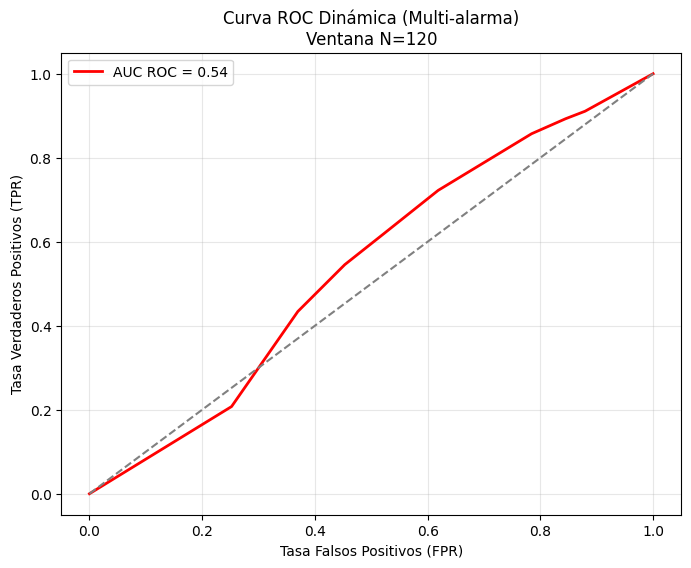

In [12]:
roc_auc=plot_dynamic_roc_curve(df_day, lda_model, dictionary, N_days_window=120, bad_topics=[3, 4, 5])

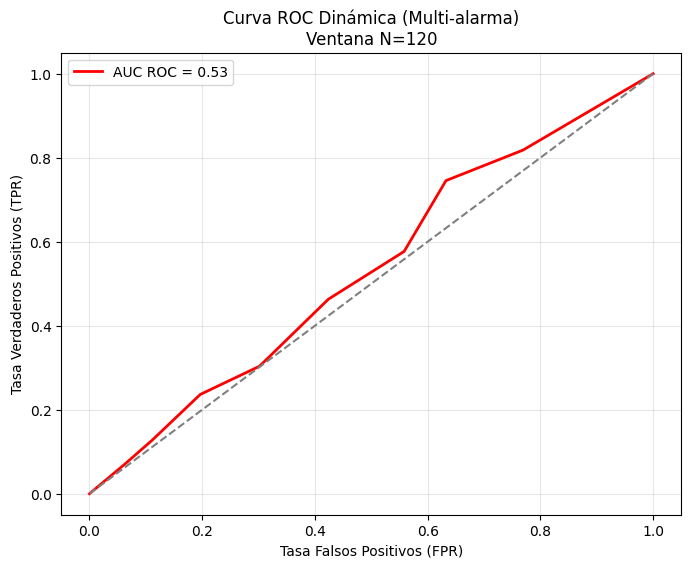

In [24]:
roc_auc=plot_dynamic_roc_curve(df_day, lda_model, dictionary, N_days_window=120, bad_topics=[3,5])

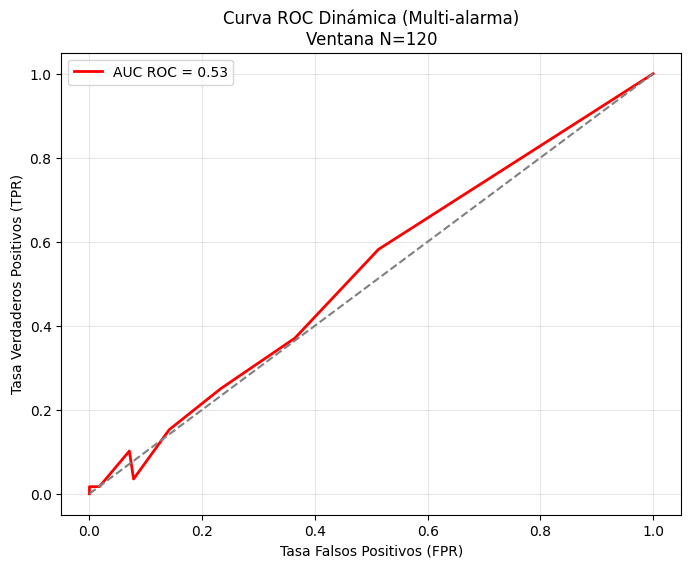

In [25]:
roc_auc=plot_dynamic_roc_curve(df_day, lda_model, dictionary, N_days_window=120, bad_topics=[3])

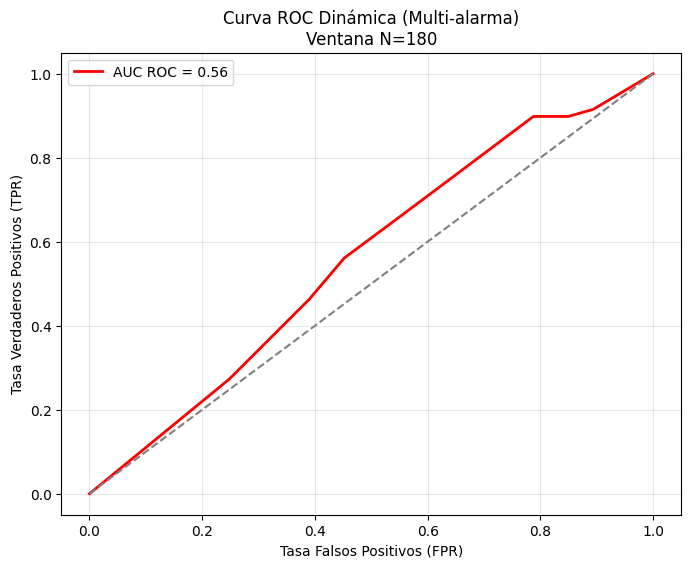

In [26]:
roc_auc=plot_dynamic_roc_curve(df_day, lda_model, dictionary, N_days_window=180, bad_topics=[3,4,5])

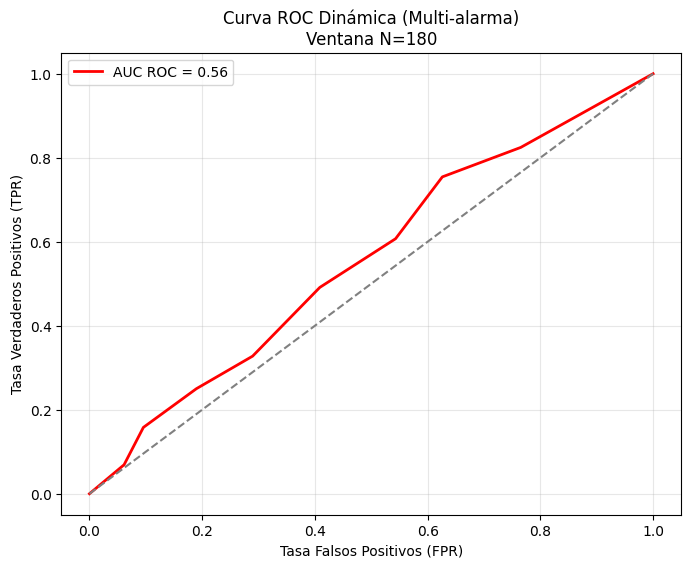

In [27]:
roc_auc=plot_dynamic_roc_curve(df_day, lda_model, dictionary, N_days_window=180, bad_topics=[3,5])

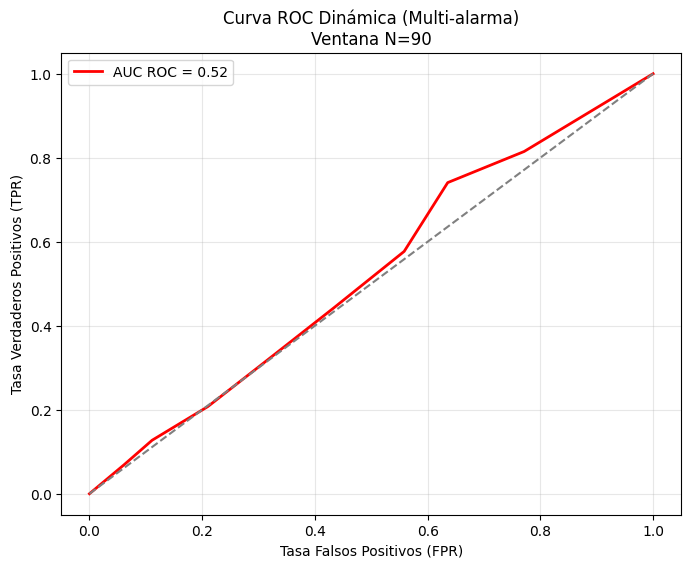

In [28]:
roc_auc=plot_dynamic_roc_curve(df_day, lda_model, dictionary, N_days_window=90, bad_topics=[3,5])

### ventana movil

In [7]:
# Complete, well-commented, runnable code for this single file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import ast

def get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary, window_size=30, min_size=15):
    """
    Obtiene las distribuciones de tópicos para un paciente específico.
    """
    row = df[df['id'] == patient_id]
    if row.empty: return []
    embedding_ids = row.iloc[0]['embedding_ids']
    if isinstance(embedding_ids, str): 
        embedding_ids = ast.literal_eval(embedding_ids)
    
    n_tokens = len(embedding_ids)
    topic_distributions = []

    # Cálculo día a día (paso a paso)
    if n_tokens >= window_size:
        for start in range(0, n_tokens - window_size + 1):
            window = embedding_ids[start:start + window_size]
            bow = dictionary.doc2bow([str(token) for token in window])
            topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
            topic_probs = [prob for _, prob in sorted(topics, key=lambda x: x[0])]
            topic_distributions.append(topic_probs)
    return topic_distributions

def analyze_dynamic_alarm_system(df, lda_model, dictionary, 
                                 threshold_t=0.6,    
                                 W_start=30,          # Tamaño mínimo de ventana para empezar (1 mes)
                                 W_max=90,            # Tamaño máximo de la ventana móvil (p.ej. 3 meses)
                                 H_horizon=120,       
                                 bad_topics=[3, 4, 5], 
                                 silent=False):
    """
    Sistema de alarma con Ventana Expansiva Inicial y luego Ventana Móvil.
    - Del día W_start al W_max: La ventana crece usando todo el historial.
    - A partir de W_max: La ventana se mueve usando solo los últimos W_max días.
    """
    results = []
    detailed_counts = {'TP': 0, 'FP_no_event': 0, 'FP_too_early': 0, 'FN_no_alarm': 0, 'FN_late': 0, 'TN': 0}
    positive_patients_report = []

    for _, row in df.iterrows():
        patient_id = row['id']
        has_pd_event = (row['Evento PD'] == 1)
        time_to_pd = row['Evento PD diff']
        
        topic_distributions = get_topic_distributions_with_entropy(df, patient_id, lda_model, dictionary)
        if not topic_distributions: continue
            
        p_bad = [np.sum([probs[i] for i in bad_topics]) for probs in topic_distributions]
        
        potential_alarms = []
        max_seen_avg = 0
        
        # MONITORIZACIÓN CON LÓGICA MIXTA
        for d in range(W_start, len(p_bad)):
            if d <= W_max:
                # FASE EXPANSIVA: Promedio desde el inicio hasta el día actual
                current_avg = np.mean(p_bad[:d])
            else:
                # FASE MÓVIL: Promedio de los últimos W_max días
                current_avg = np.mean(p_bad[d - W_max : d])
            
            max_seen_avg = max(max_seen_avg, current_avg)
            
            if current_avg >= threshold_t:
                potential_alarms.append(d)

        # Selección de la alarma (Prioridad a TP)
        best_alarm = None
        if potential_alarms:
            if not has_pd_event:
                best_alarm = potential_alarms[0]
            else:
                found_tp = False
                for alarm in potential_alarms:
                    if alarm < time_to_pd <= (alarm + H_horizon):
                        best_alarm = alarm
                        found_tp = True
                        break
                if not found_tp:
                    best_alarm = potential_alarms[0]

        # Clasificación
        final_case = ""
        if has_pd_event:
            if best_alarm is None: final_case = 'FN_no_alarm'
            elif best_alarm >= time_to_pd: final_case = 'FN_late'
            elif best_alarm < time_to_pd <= (best_alarm + H_horizon): final_case = 'TP'
            else: final_case = 'FP_too_early'
            
            positive_patients_report.append({
                'id': patient_id, 'dia_evento': time_to_pd, 'dia_alarma': best_alarm,
                'max_avg': max_seen_avg, 'resultado': final_case
            })
        else:
            final_case = 'FP_no_event' if best_alarm is not None else 'TN'

        detailed_counts[final_case] += 1
        results.append({'id': patient_id, 'case': final_case, 'alarm_day': best_alarm})

    if not silent:
        print("\n" + "="*95)
        print(f"📊 REPORTE MIXTO (W_start={W_start}, W_max={W_max}, T={threshold_t})")
        print("="*95)
        print(f"{'ID':<12} | {'Día Evento':<10} | {'Día Alarma':<10} | {'Max Avg':<10} | {'Resultado'}")
        print("-" * 95)
        for p in positive_patients_report:
            alarm_str = f"{p['dia_alarma']}" if p['dia_alarma'] is not None else "Nunca"
            print(f"{p['id']:<12} | {p['dia_evento']:<10.1f} | {alarm_str:<10} | {p['max_avg']:<10.4f} | {p['resultado']}")
        
        print("\n" + "="*95)
        tp = detailed_counts['TP']
        fn = detailed_counts['FN_no_alarm'] + detailed_counts['FN_late']
        print(f"TP: {tp} | FN: {fn} | Sensibilidad: {tp/(tp+fn):.2%}" if (tp+fn)>0 else "Sensibilidad: 0%")
        print("="*85 + "\n")

    return results, detailed_counts

def plot_dynamic_roc_curve(df, lda_model, dictionary, W_start=30, W_max=90, bad_topics=[3, 4, 5], H_horizon=120):
    """ 
    Genera la curva ROC probando umbrales de 0 a 1.
    Asegura que los puntos de anclaje (0,0) y (1,1) estén presentes para una curva completa.
    """
    # Probamos más umbrales para que la curva sea más suave, incluyendo los extremos 0 y 1
    t_thresholds = np.linspace(0.0, 1.0, 15)
    tpr_list = []
    fpr_list = []

    for t in t_thresholds:
        res, counts = analyze_dynamic_alarm_system(df, lda_model, dictionary, threshold_t=t, 
                                                 W_start=W_start, W_max=W_max, H_horizon=H_horizon, 
                                                 bad_topics=bad_topics, silent=True)
        tp = counts['TP']
        fn = counts['FN_no_alarm'] + counts['FN_late']
        fp = counts['FP_no_event'] + counts['FP_too_early']
        tn = counts['TN']
        
        tpr_list.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
        fpr_list.append(fp/(fp+tn) if (fp+tn)>0 else 0.0)

    # Forzamos los puntos de anclaje para asegurar que la curva toque las esquinas
    if (0.0, 0.0) not in zip(fpr_list, tpr_list):
        fpr_list.append(0.0); tpr_list.append(0.0)
    if (1.0, 1.0) not in zip(fpr_list, tpr_list):
        fpr_list.append(1.0); tpr_list.append(1.0)

    # Ordenar puntos por FPR para un dibujo correcto de la línea
    points = sorted(set(zip(fpr_list, tpr_list)))
    fpr_s, tpr_s = zip(*points)
    roc_auc = auc(fpr_s, tpr_s)

    plt.figure(figsize=(7, 5))
    # Añadimos marcadores 'o' para ver los puntos de umbral probados
    plt.plot(fpr_s, tpr_s, 'r-', marker='o', markersize=4, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1], 'k--', alpha=0.5)
    
    # Ajustamos límites para que no se vea cortada la línea en los bordes
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    
    plt.title(f'Curva ROC Completa - Ventana Mixta (W_max={W_max})')
    plt.xlabel('Tasa Falsos Positivos (FPR)')
    plt.ylabel('Tasa Verdaderos Positivos (TPR)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    return roc_auc

### ventana movil

In [9]:
plot_dynamic_roc_curve(df_day, lda_model, dictionary, W_start=30, W_max=60, bad_topics=[3, 4, 5],H_horizon=120)

In [ ]:
plot_dynamic_roc_curve(df_day, lda_model, dictionary, W_start=30, W_max=120, bad_topics=[3, 4, 5],H_horizon=120)

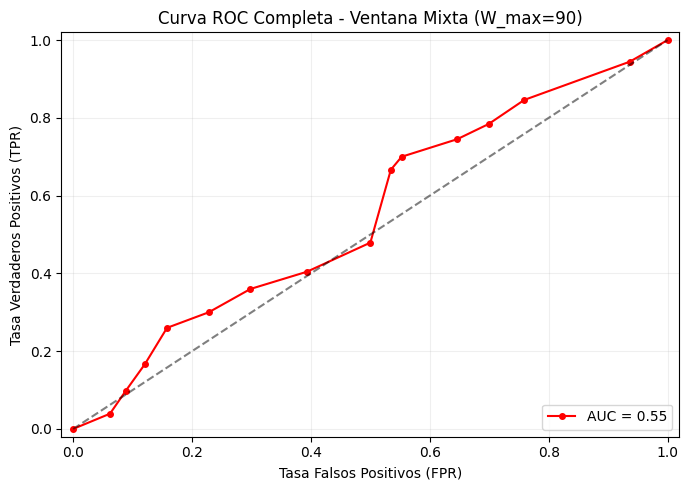

0.5512288675439465

In [8]:
plot_dynamic_roc_curve(df_day, lda_model, dictionary, W_start=30, W_max=90, bad_topics=[3, 5],H_horizon=120)

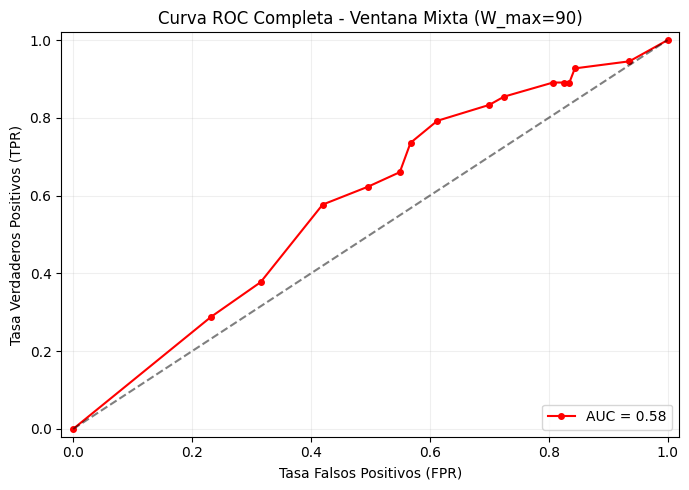

0.5833570326189765

In [11]:
plot_dynamic_roc_curve(df_day, lda_model, dictionary, W_start=30, W_max=90, bad_topics=[3, 4, 5],H_horizon=180)

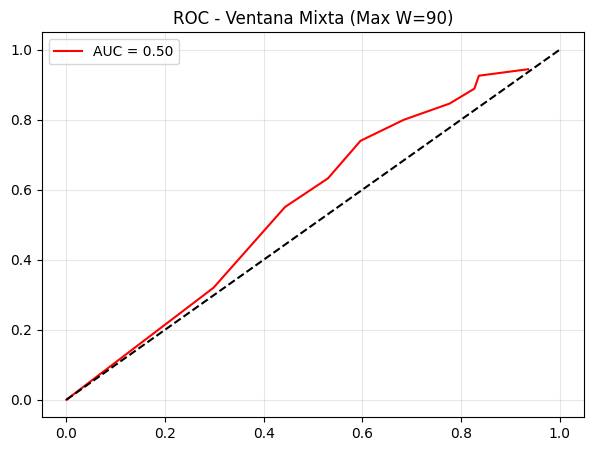

0.4970765526653072

In [20]:
plot_dynamic_roc_curve(df_day, lda_model, dictionary, W_start=30, W_max=90, bad_topics=[3, 4, 5],H_horizon=120)

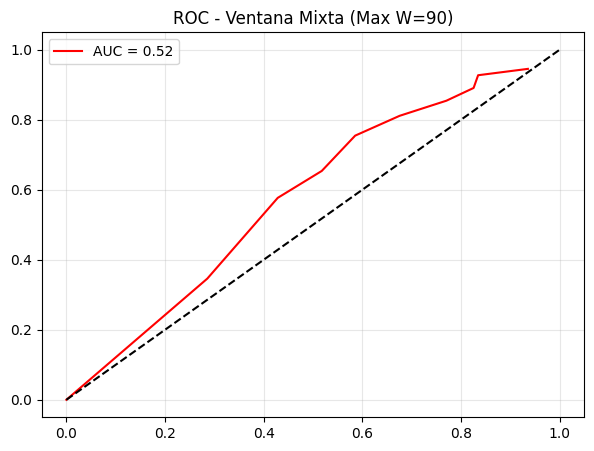

0.5185482977362413

In [21]:
plot_dynamic_roc_curve(df_day, lda_model, dictionary, W_start=30, W_max=90, bad_topics=[3, 4, 5],H_horizon=180)